In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

**Za pocetak ucitavam podatke i ispisujem tipove podataka po kolonama.**

In [2]:
file_path = 'Summer_olympic_Medals.csv'

data = pd.read_csv(file_path)
data.dtypes

,0
Year,int64
Host_country,object
Host_city,object
Country_Name,object
Country_Code,object
Gold,int64
Silver,int64
Bronze,int64


**Ovde mozemo videti sve razlicite domacine OI ukupno 19 zemalja.**

In [4]:
# Izvrsio sam zamenu imena zemljama koje ne postoje vise pod tim imenom
data['Host_country'] = data['Host_country'].replace({
    'Australia/Sweden': 'Australia',
    'West Germany': 'Germany',
    'Soviet Union': 'Russia'
})
data['Total'] = data['Gold'] + data['Silver'] + data['Bronze']
Domacini = data['Host_country'].drop_duplicates().reset_index(drop=True)
print(Domacini)

0            Greece
1            France
2     United States
3     Great Britain
4            Sweden
5           Belgium
6       Netherlands
7           Germany
8           Finland
9         Australia
10            Italy
11            Japan
12           Mexico
13           Canada
14           Russia
15      South Korea
16            Spain
17            China
18           Brazil
Name: Host_country, dtype: object


**Broj medalja po zemljama pojedinacno(zlato, srebro, bronza) i ukupan broj medalja**
**Takodje sam zamenio nazive nekih zemalja sa njihovim sadasnjim nazivima ili naslednicima tih zemalja.**

In [5]:
data['Country_Name'] = data['Country_Name'].replace({
    'Bohemia': 'Czech Republic',
    'Russian Empire': 'Russia',
    'Australasia': 'Australia',
    'Czechoslovakia': 'Czech Republic',
    'Yugoslavia': 'Serbia',
    'Ceylon': 'Sri Lanka',
    'Soviet Union': 'Russia',
    'United Team of Germany': 'Germany',
    'Republic of China': 'Chinese Taipei',
    'East Germany': 'Germany',
    'West Germany': 'Germany',
    'Unified Team': 'Russia',
    'Serbia and Montenegro': 'Serbia',
    'ROC': 'Russia',
    'North Macedonia': 'Macedonia',
})
Ukupan_ucinak = data.groupby('Country_Name')[['Gold', 'Silver', 'Bronze', 'Total']].sum()
# Sortiranje, najpre po zlatnim, zatim srebrnim, a na kraju i bronzanim medaljama
Ukupan_ucinak_sortirano = Ukupan_ucinak.sort_values(by=['Gold', 'Silver', 'Bronze'], ascending=False)

print(Ukupan_ucinak_sortirano)

               Gold  Silver  Bronze  Total
Country_Name                              
United States  1060     832     738   2630
Russia          610     514     503   1627
Germany         439     457     491   1387
Great Britain   284     319     315    918
China           262     199     173    634
...             ...     ...     ...    ...
Eritrea           0       0       1      1
Guyana            0       0       1      1
Iraq              0       0       1      1
Mauritius         0       0       1      1
Togo              0       0       1      1

[142 rows x 4 columns]


**Sada izvlacim broj drzava sa ukupno n osvojenih medalja.**

In [6]:
def broj_drzava_sa_n_medalja(broj_medalja, data):
    broj_drzava = Ukupan_ucinak_sortirano[Ukupan_ucinak_sortirano['Total'] == broj_medalja].shape[0]
    print(f"Broj država sa tacno {broj_medalja} osvojenih medalja je {broj_drzava}.")

In [7]:
random_numbers = [random.randint(1, 100) for _ in range(5)]

In [8]:
broj_drzava_sa_n_medalja(1, data)

Broj država sa tacno 1 osvojenih medalja je 20.


In [9]:
for i in random_numbers:
  broj_drzava_sa_n_medalja(i, data)

Broj država sa tacno 72 osvojenih medalja je 2.
Broj država sa tacno 59 osvojenih medalja je 0.
Broj država sa tacno 64 osvojenih medalja je 0.
Broj država sa tacno 30 osvojenih medalja je 1.
Broj država sa tacno 47 osvojenih medalja je 0.


**U nastavku mozemo na grafiku videti kako se mediana ukupno osvojenih medalja kretala kroz godine.**

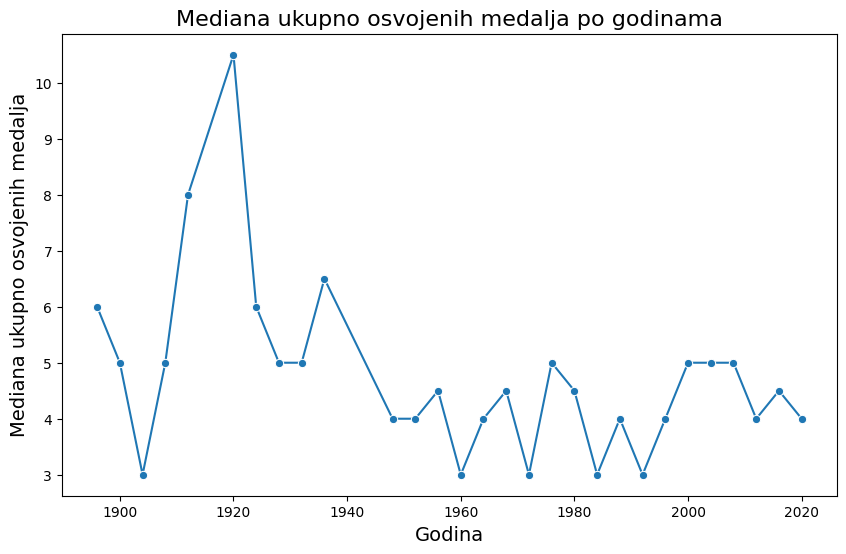

In [10]:
# Prvo grupisem podatke po godinama, a zatim za svaku godinu racunam medianu
median_medals_per_year = data.groupby('Year')['Total'].median()

# Kreiram grafik
plt.figure(figsize=(10, 6))
sns.lineplot(x=median_medals_per_year.index, y=median_medals_per_year.values, marker='o')

plt.title('Mediana ukupno osvojenih medalja po godinama', fontsize=16)
plt.xlabel('Godina', fontsize=14)
plt.ylabel('Mediana ukupno osvojenih medalja', fontsize=14)

plt.show()

**Sada definisem novu funkciju, koja za unetu godinu ispisuje sve zemlje koje su te godine "imale problem sa zlatima", tacnije osvajale su odredjeni broj medalja ali sa malim udelom zlata.**

In [11]:
def problem_sa_zlatima(year, data):
    # Najpre uzimam sve podatke za posmatranu godinu
    year_data = data[data['Year'] == year]

    # Za posmatranu godinu grupisem podatke po zemljama i uzimam kolone Gold i Total
    country_summary = year_data.groupby('Country_Name')[['Gold', 'Total']].sum()

    # Dodeljujem kriterijum za izbor takvih zemalja
    filtered_countries = country_summary[
        ((country_summary['Total'] > 5) & (country_summary['Gold'] == 0)) |
        ((country_summary['Total'] > 10) & (country_summary['Gold'] <= 1)) |
        ((country_summary['Total'] > 15) & (country_summary['Gold'] <= 2)) |
        ((country_summary['Total'] > 20) & (country_summary['Gold'] <= 3)) |
        ((country_summary['Total'] > 25) & (country_summary['Gold'] <= 4))
        ]

    # Najpre dodajem ispis u slucaju godina kada igre nisu odrzane
    if year in [1916, 1940, 1944] or year % 4 != 0:
        print(f"{year}. godine nisu odrzane Olimpijske Igre.")
    # Zatim slucaj kada nije bilo takvih zemalja
    elif filtered_countries.empty:
        print(f"Nijedna zemlja nije imala problem sa osvajanjem zlata {year}. godine.")
    # I na kraju ispis za godine kada je bilo takvih zemalja
    else:
        for country in filtered_countries.index:
            total_medals = filtered_countries.loc[country, 'Total']
            gold_medals = filtered_countries.loc[country, 'Gold']
            print(f"{country} je {year}. godine imala problem sa osvajanjem zlata. Osvojila je ukupno {total_medals} medalja, ali samo {gold_medals} zlata.")



**Izvlacim podatke za sve godine u kojima su igre trebale biti odrzane (1896-2020)**

In [12]:
for i in range(1896, 2020, 4):
  problem_sa_zlatima(i, data)

Nijedna zemlja nije imala problem sa osvajanjem zlata 1896. godine.
Austria je 1900. godine imala problem sa osvajanjem zlata. Osvojila je ukupno 6 medalja, ali samo 0 zlata.
Nijedna zemlja nije imala problem sa osvajanjem zlata 1904. godine.
Nijedna zemlja nije imala problem sa osvajanjem zlata 1908. godine.
Denmark je 1912. godine imala problem sa osvajanjem zlata. Osvojila je ukupno 12 medalja, ali samo 1 zlata.
1916. godine nisu odrzane Olimpijske Igre.
Nijedna zemlja nije imala problem sa osvajanjem zlata 1920. godine.
Sweden je 1924. godine imala problem sa osvajanjem zlata. Osvojila je ukupno 29 medalja, ali samo 4 zlata.
Nijedna zemlja nije imala problem sa osvajanjem zlata 1928. godine.
Denmark je 1932. godine imala problem sa osvajanjem zlata. Osvojila je ukupno 6 medalja, ali samo 0 zlata.
Poland je 1936. godine imala problem sa osvajanjem zlata. Osvojila je ukupno 6 medalja, ali samo 0 zlata.
Switzerland je 1936. godine imala problem sa osvajanjem zlata. Osvojila je ukupno 

**Ovde su neki od najdrasticnijih primera kada su zemlje osvajale medalje, ali nisu bile dobro pozicionirane zbog malog broja zlatnih medalja.**

In [13]:
problem_sa_zlatima(1980, data)

Poland je 1980. godine imala problem sa osvajanjem zlata. Osvojila je ukupno 32 medalja, ali samo 3 zlata.


In [14]:
problem_sa_zlatima(2008, data)

Cuba je 2008. godine imala problem sa osvajanjem zlata. Osvojila je ukupno 30 medalja, ali samo 3 zlata.


**I jedan primer za godinu kada je bilo cak 4 takve zemlje.**

In [15]:
problem_sa_zlatima(2000, data)

Brazil je 2000. godine imala problem sa osvajanjem zlata. Osvojila je ukupno 12 medalja, ali samo 0 zlata.
Georgia je 2000. godine imala problem sa osvajanjem zlata. Osvojila je ukupno 6 medalja, ali samo 0 zlata.
Jamaica je 2000. godine imala problem sa osvajanjem zlata. Osvojila je ukupno 9 medalja, ali samo 0 zlata.
Ukraine je 2000. godine imala problem sa osvajanjem zlata. Osvojila je ukupno 23 medalja, ali samo 3 zlata.


**Postoje i situacije kada zemlje osvoje veliki broj zlata u odnosu na ukupan broj osvojenih medalja, sto im zbog sortiranja najpre po zlatima cesto donosi daleko bolji plasman.**

In [16]:
def prednost_zbog_zlata(year, data):
    # Uzimam sve podatke za posmatranu godinu
    year_data = data[data['Year'] == year]

    # Grupisem podatke po zemljama i uzimam kolone Gold i Total
    country_summary = year_data.groupby('Country_Name')[['Gold', 'Total']].sum()

    # Filtriram zemalje na osnovu datog kriterijuma
    filtered_countries = country_summary[
        (2*country_summary['Gold'] >= country_summary['Total'])   # Vise ili jednako od pola medalja su zlatne
    ]

    # Slican nacin ispisivanja kao i za prethodnu funkciju, samo prilagodjen za ovu
    if year in [1916, 1940, 1944] or year % 4 != 0:
        print(f"{year}. godine nisu održane Olimpijske Igre.")
    elif filtered_countries.empty:
        print(f"Nijedna zemlja nije imala prednost zbog osvojenih zlata {year}. godine.")
    else:
        for country in filtered_countries.index:
            total_medals = filtered_countries.loc[country, 'Total']
            gold_medals = filtered_countries.loc[country, 'Gold']
            print(f"{country} je {year}. godine imala vise od pola zlata. Osvojila je ukupno {total_medals} medalja, od cega {gold_medals} zlata.")

**Ovde vidimo kako u pocetnim godinama OI se cesto desavalo da domacin ili neka druga zemlja uzmu vise od pola zlatnih medalja, a da ukupan broj medalja bude bar 20. Dok je u poslednjih nekoliko OI to gotovo nezamislivo. U nastavku su neki od najdrasticnijih primera. Odavde takodje vidimo kako se u poslednjih nekoliko godina povecanjem broja osvajaca medalja povecao i broj onih koje osvajaju vecinski zlata, ali su to sada drzave koje osvajaju tek nekoliko odlicja, pa je lakse da bar pola bude zlatnih.**

In [17]:
prednost_zbog_zlata(1916, data)

1916. godine nisu održane Olimpijske Igre.


In [18]:
prednost_zbog_zlata(1920, data)

Italy je 1920. godine imala vise od pola zlata. Osvojila je ukupno 23 medalja, od cega 13 zlata.


In [19]:
prednost_zbog_zlata(1952, data)

Australia je 1952. godine imala vise od pola zlata. Osvojila je ukupno 11 medalja, od cega 6 zlata.
Belgium je 1952. godine imala vise od pola zlata. Osvojila je ukupno 4 medalja, od cega 2 zlata.
Czech Republic je 1952. godine imala vise od pola zlata. Osvojila je ukupno 13 medalja, od cega 7 zlata.
India je 1952. godine imala vise od pola zlata. Osvojila je ukupno 2 medalja, od cega 1 zlata.
Luxembourg je 1952. godine imala vise od pola zlata. Osvojila je ukupno 1 medalja, od cega 1 zlata.
Norway je 1952. godine imala vise od pola zlata. Osvojila je ukupno 5 medalja, od cega 3 zlata.
Turkey je 1952. godine imala vise od pola zlata. Osvojila je ukupno 3 medalja, od cega 2 zlata.
United States je 1952. godine imala vise od pola zlata. Osvojila je ukupno 76 medalja, od cega 40 zlata.


In [20]:
prednost_zbog_zlata(1972, data)

Denmark je 1972. godine imala vise od pola zlata. Osvojila je ukupno 1 medalja, od cega 1 zlata.
Netherlands je 1972. godine imala vise od pola zlata. Osvojila je ukupno 5 medalja, od cega 3 zlata.
Norway je 1972. godine imala vise od pola zlata. Osvojila je ukupno 4 medalja, od cega 2 zlata.
Russia je 1972. godine imala vise od pola zlata. Osvojila je ukupno 99 medalja, od cega 50 zlata.
Uganda je 1972. godine imala vise od pola zlata. Osvojila je ukupno 2 medalja, od cega 1 zlata.


In [21]:
prednost_zbog_zlata(2020, data)

Bahamas je 2020. godine imala vise od pola zlata. Osvojila je ukupno 2 medalja, od cega 2 zlata.
Bermuda je 2020. godine imala vise od pola zlata. Osvojila je ukupno 1 medalja, od cega 1 zlata.
Bulgaria je 2020. godine imala vise od pola zlata. Osvojila je ukupno 6 medalja, od cega 3 zlata.
Ecuador je 2020. godine imala vise od pola zlata. Osvojila je ukupno 3 medalja, od cega 2 zlata.
Estonia je 2020. godine imala vise od pola zlata. Osvojila je ukupno 2 medalja, od cega 1 zlata.
Fiji je 2020. godine imala vise od pola zlata. Osvojila je ukupno 2 medalja, od cega 1 zlata.
Greece je 2020. godine imala vise od pola zlata. Osvojila je ukupno 4 medalja, od cega 2 zlata.
Ireland je 2020. godine imala vise od pola zlata. Osvojila je ukupno 4 medalja, od cega 2 zlata.
Israel je 2020. godine imala vise od pola zlata. Osvojila je ukupno 4 medalja, od cega 2 zlata.
Kosovo je 2020. godine imala vise od pola zlata. Osvojila je ukupno 2 medalja, od cega 2 zlata.
Latvia je 2020. godine imala vise o

**Grafici koji prikazuju ukupan broj osvojenih medalja kao i broj zlatnih medalja prvih 10 zemalja i Srbije.**

**Ovde mozemo videti da u prvih 4 nema promena, ali obzirom da se rangiranje obavlja po broju zlatnih medalja u nastavku poredak ne bi bio isti da se rangiranje radi po ukupnom broju medalja.**

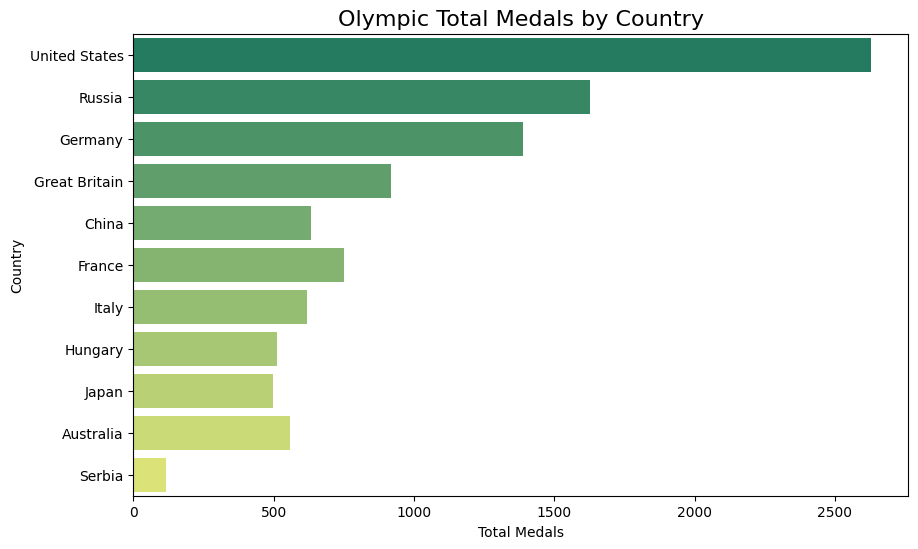

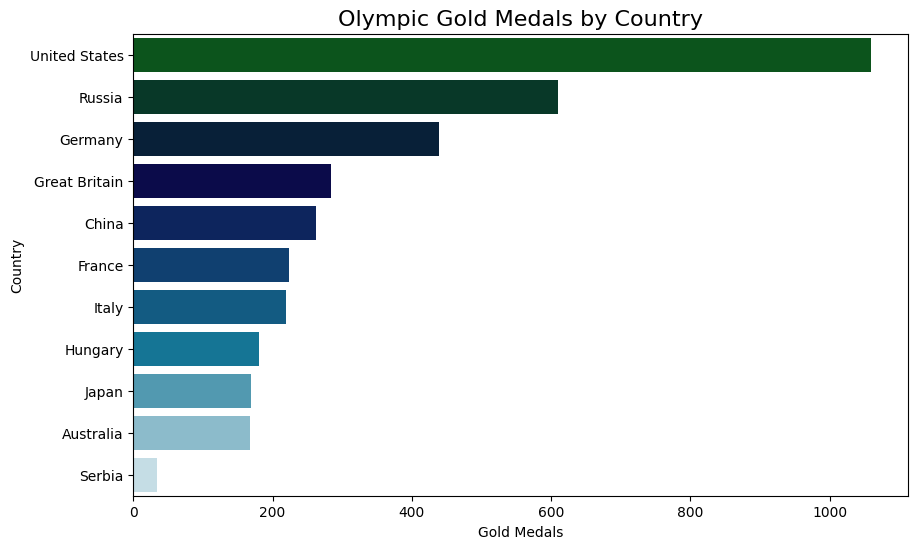

In [22]:
# Za pocetak uzimam podatke o prvih 10 i Srbiji
top_10 = Ukupan_ucinak_sortirano.head(10)
serbia = Ukupan_ucinak_sortirano.loc[['Serbia']]

# Pa zatim spajam podatke za top10 i Srbiju

if 'Serbia' not in top_10.index:                           # Iako Srbija nije u prvih 10 ostavljam ovaj uslov kao sigurnost da se podaci za Srbiju nece ponoviti
    final_selection = pd.concat([top_10, serbia])          # Jer ukoliko bi posmatrali neku zemlju iz top 10 ovaj uslov bi bio potreban kako ne bi bilo ponavljanja
else:
    final_selection = top_10

# I na kraju pravim grafike
# Najpre za ukupan broj osvojenih medalja

plt.figure(figsize=(10, 6))
sns.barplot(x='Total', y=final_selection.index, hue=final_selection.index, data=final_selection, palette='summer', dodge=False, legend=False)

plt.title('Olympic Total Medals by Country', fontsize=16)
plt.xlabel('Total Medals')
plt.ylabel('Country')

plt.show()

# A zatim i za broj osvojenih zlata

plt.figure(figsize=(10, 6))
sns.barplot(x='Gold', y=final_selection.index, hue=final_selection.index, data=final_selection, palette='ocean', dodge=False, legend=False)

plt.title('Olympic Gold Medals by Country', fontsize=16)
plt.xlabel('Gold Medals')
plt.ylabel('Country')

plt.show()

**U nastavku je funkcija koja za unetu godinu, izbacuje grafik sa brojem osvojenih medalja u toj godini za top10 i Srbiju uz posebno naznacavanje domacina na grafiku.**

In [23]:
def analiza_medalja_po_godinama(year, data, additional_country='Serbia'):
    # Izvlacim podatke za odabranu godinu
    year_data = data[data['Year'] == year]

    # Grupisem podatke po zemljama i uzimam kolone Gold, Silver, Bronze i Total
    medals_summary = year_data.groupby('Country_Name')[['Gold', 'Silver', 'Bronze', 'Total']].sum()

    # Sortiram zemlje (najpre po broju osvojenih zlata, srebra a potom i bronzi) u opadajućem redosledu
    medals_summary_sorted = medals_summary.sort_values(by=['Gold', 'Silver', 'Bronze'], ascending=False)

    # Provera koja zemlja je domacin u datoj godini
    host_country = data[data['Year'] == year]['Host_country'].iloc[0]

    # Odabir prvih 10 zemalja
    top10_countries = medals_summary_sorted.head(10)

    # Dodajem Srbiju, a u samoj funkciji ostavljam mogucnost da se odabere neka druga zemlja(Srbiju ostavljam kao podrazumevanu ukoliko se nista ne navede)
    if additional_country in medals_summary_sorted.index and additional_country not in top10_countries.index:
        additional_country_data = medals_summary_sorted.loc[[additional_country]]
        top10_countries = pd.concat([top10_countries, additional_country_data])

    # Dodavanje zemlje domacina ako nije vec u top 10
    if host_country not in top10_countries.index:
        host_country_data = medals_summary_sorted.loc[[host_country]]
        top10_countries = pd.concat([top10_countries, host_country_data])

    # Kreiranje palete boja, crvena za domacina, ostale iz summer palete
    colors = ['red' if country == host_country else color for country, color in zip(top10_countries.index, sns.color_palette('summer', len(top10_countries)))]

    # Pravljenje grafika sa dva podgrafika
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))

    # Prvi podgrafik - Ukupan broj medalja
    sns.barplot(x='Total', y=top10_countries.index, hue=top10_countries.index, data=top10_countries, palette=colors, dodge=False, ax=axes[0], legend=False)
    axes[0].set_title(f'Olympic Total Medals by Country: {year}', fontsize=16)
    axes[0].set_xlabel('Total Medals')
    axes[0].set_ylabel('Country')

    # Drugi podgrafik - Zlatne medalje
    sns.barplot(x='Gold', y=top10_countries.index, hue=top10_countries.index, data=top10_countries, palette=colors, dodge=False, ax=axes[1], legend=False)
    axes[1].set_title(f'Olympic Gold Medals by Country: {year}', fontsize=16)
    axes[1].set_xlabel('Gold Medals')
    axes[1].set_ylabel('Country')

    plt.tight_layout()
    plt.show()




**U nastavku vidimo kako je u pocetnim godinama domacinstvo donosilo apsolutnu prednost.**

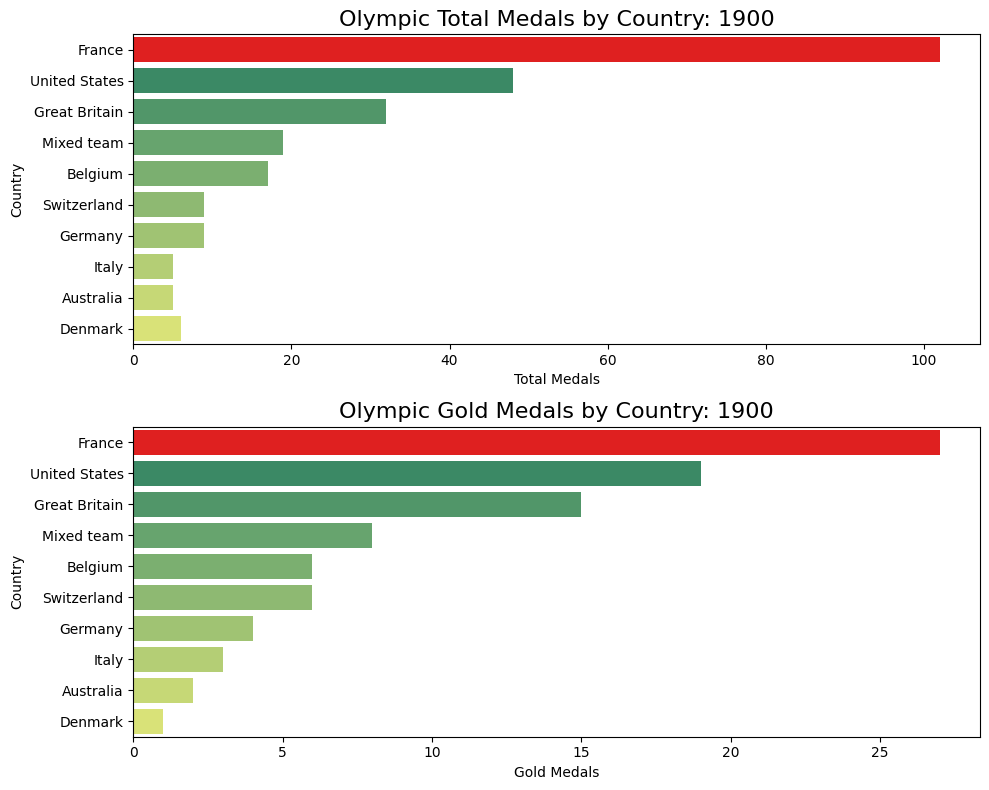

In [24]:
analiza_medalja_po_godinama(1900, data)

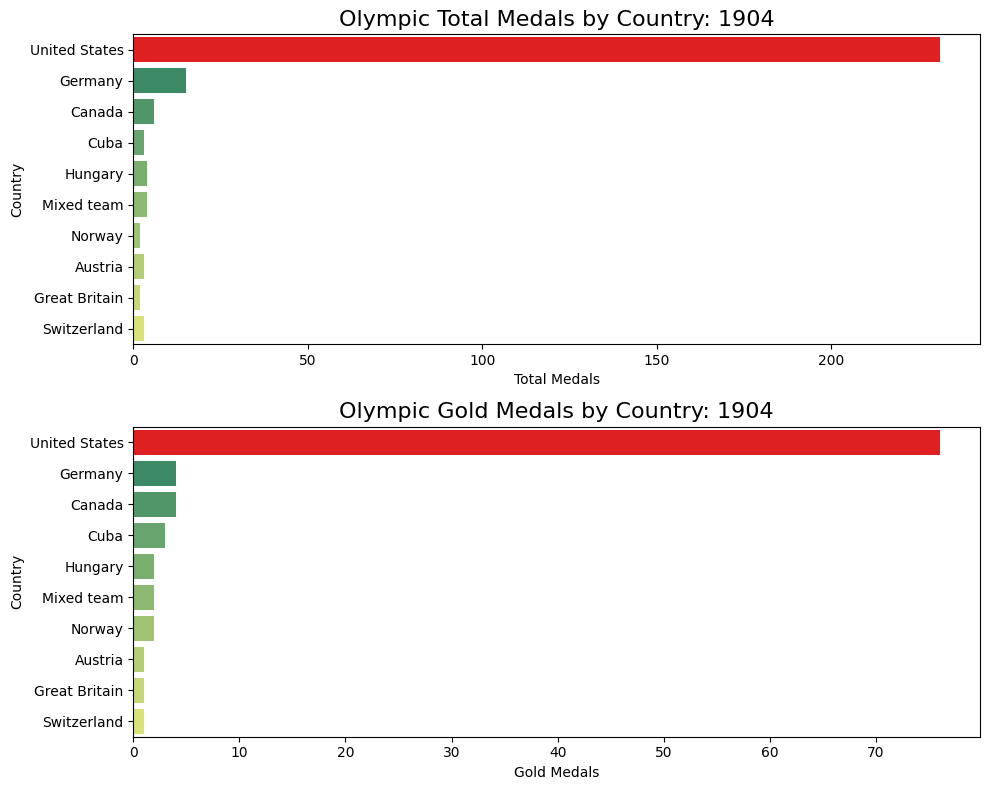

In [ ]:
analiza_medalja_po_godinama(1904, data)

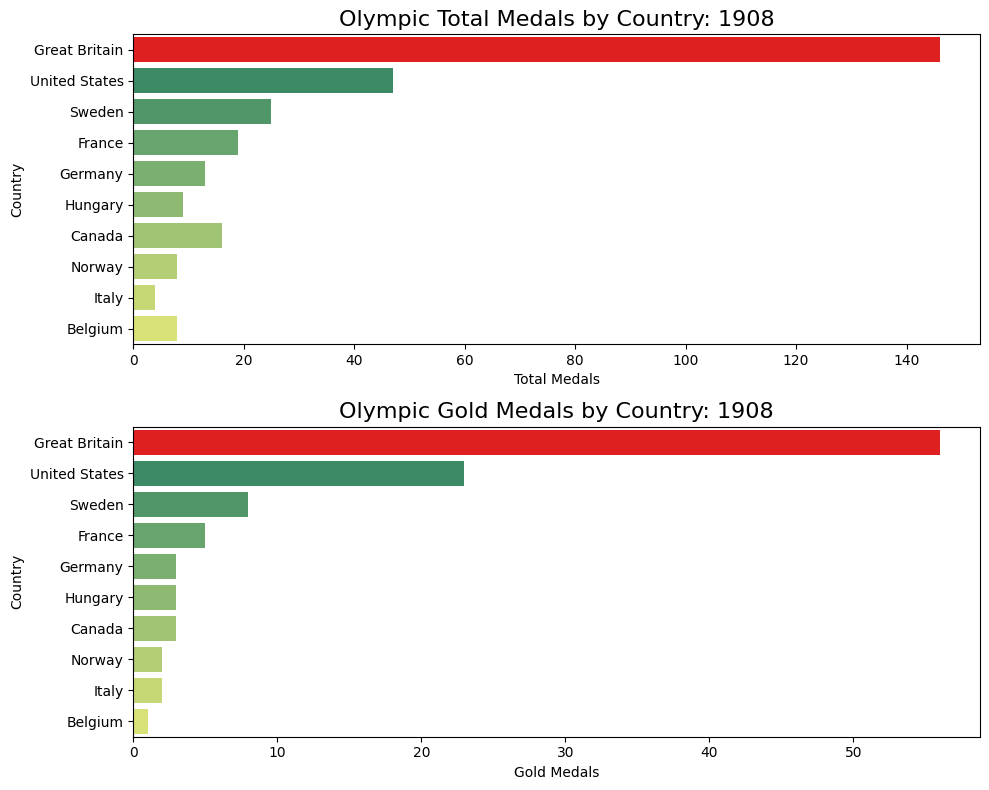

In [ ]:
analiza_medalja_po_godinama(1908, data)

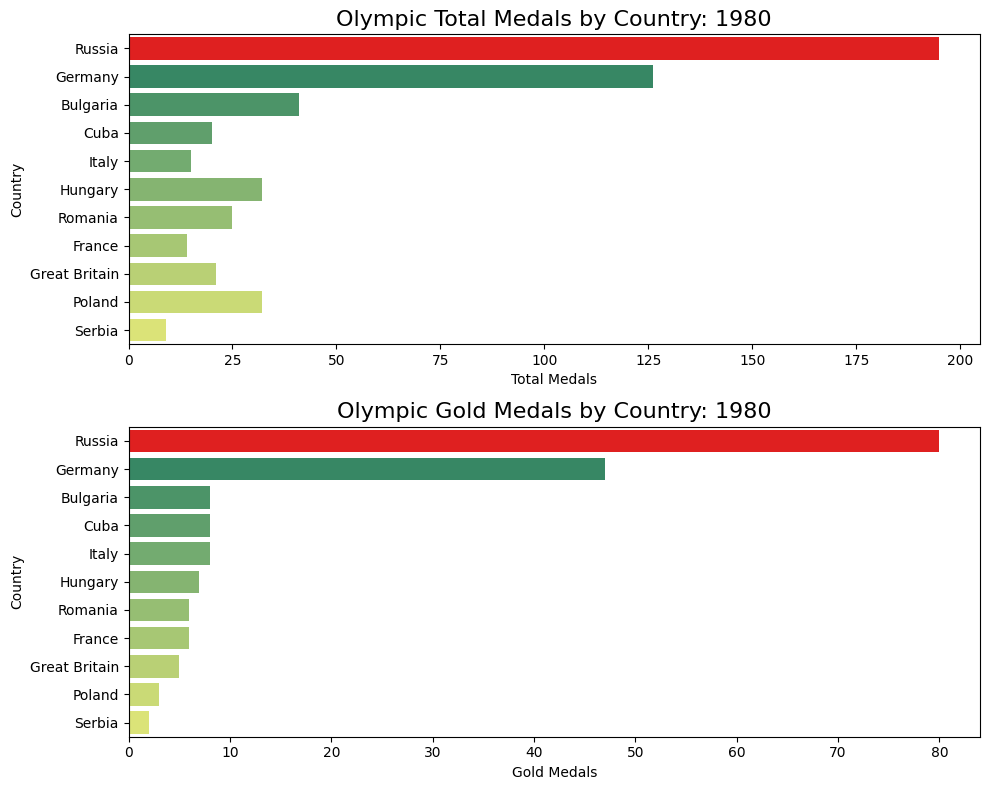

In [ ]:
analiza_medalja_po_godinama(1980, data)

**U novije doba domacinstvo prestavlja prednost, ali ni blizu na nivou kao u pocetnim godinama**

**Najpre vidimo kako Japan kao domacin dolazi do treceg mesta.**

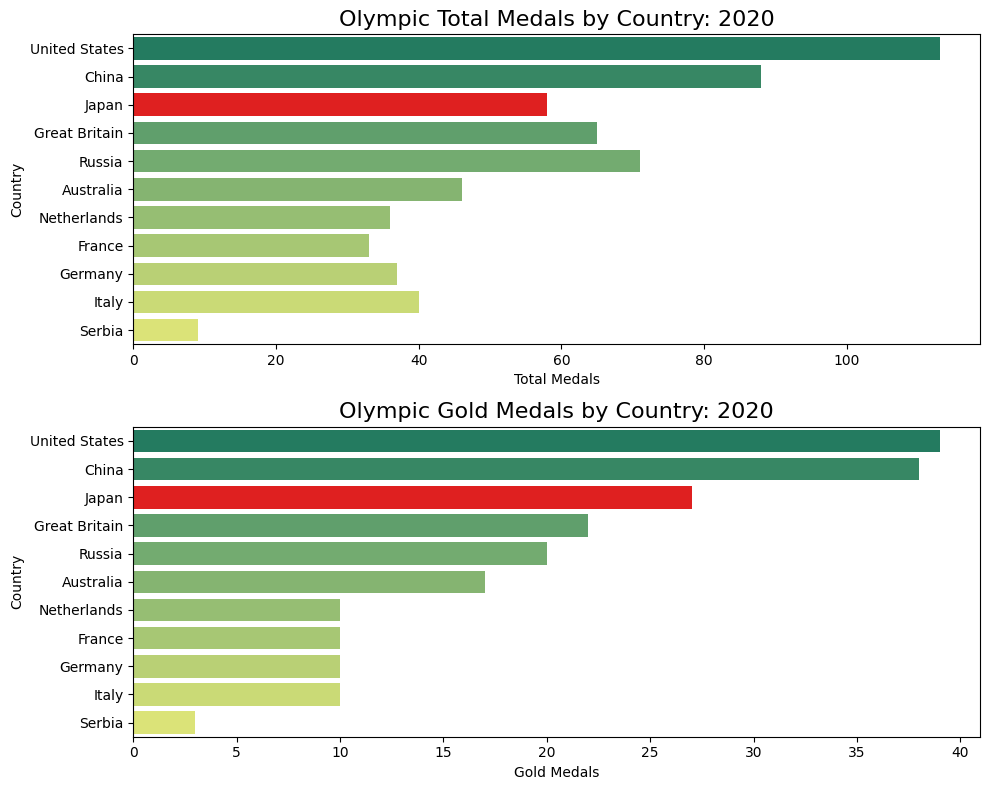

In [ ]:
analiza_medalja_po_godinama(2020, data)

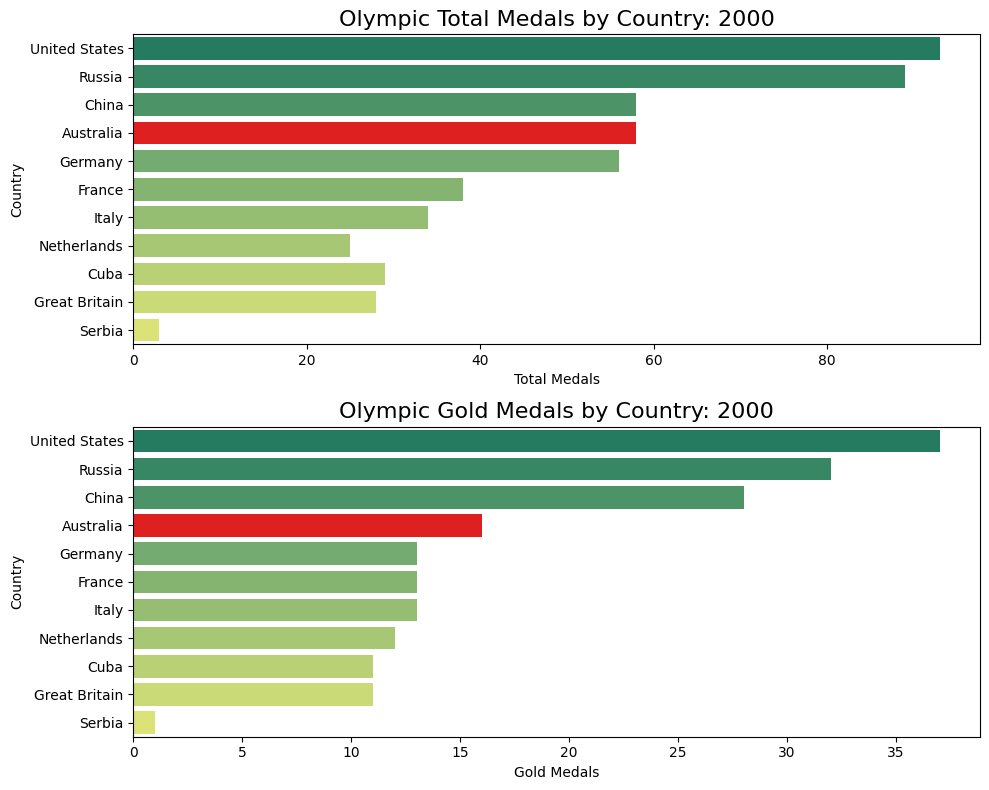

In [ ]:
analiza_medalja_po_godinama(2000, data)

**Kina je cak stigla i do prvog mesta, iako nije imala ukupno najvise medalja, zlata su prvi kriterijum.**

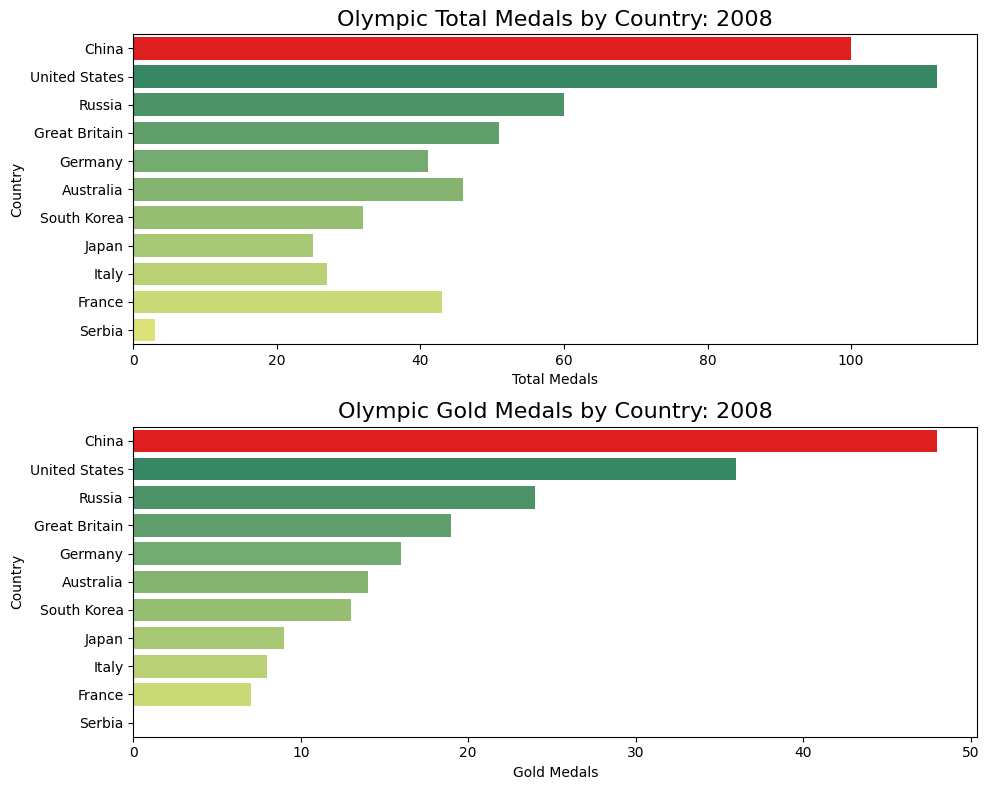

In [ ]:
analiza_medalja_po_godinama(2008, data)

**Zemlje koje se inace ne nalaze u top10 domacinstvo su iskoristile da se probiju u prvih 10.**

**Spanija je stigla do 6. pozicije 1992. godine, kao domacin u Barseloni.**

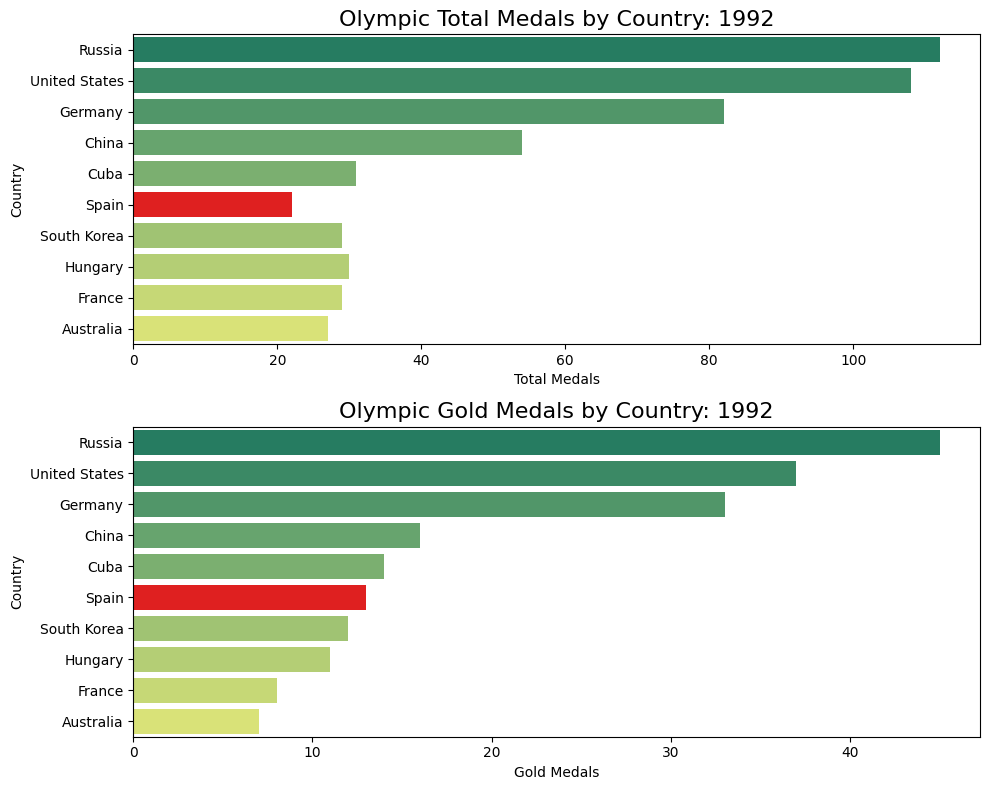

In [ ]:
analiza_medalja_po_godinama(1992, data)

**Dok je Juzna Koreja domacinstvo iskoristila da se probije cak do cetvrtog mesta.**

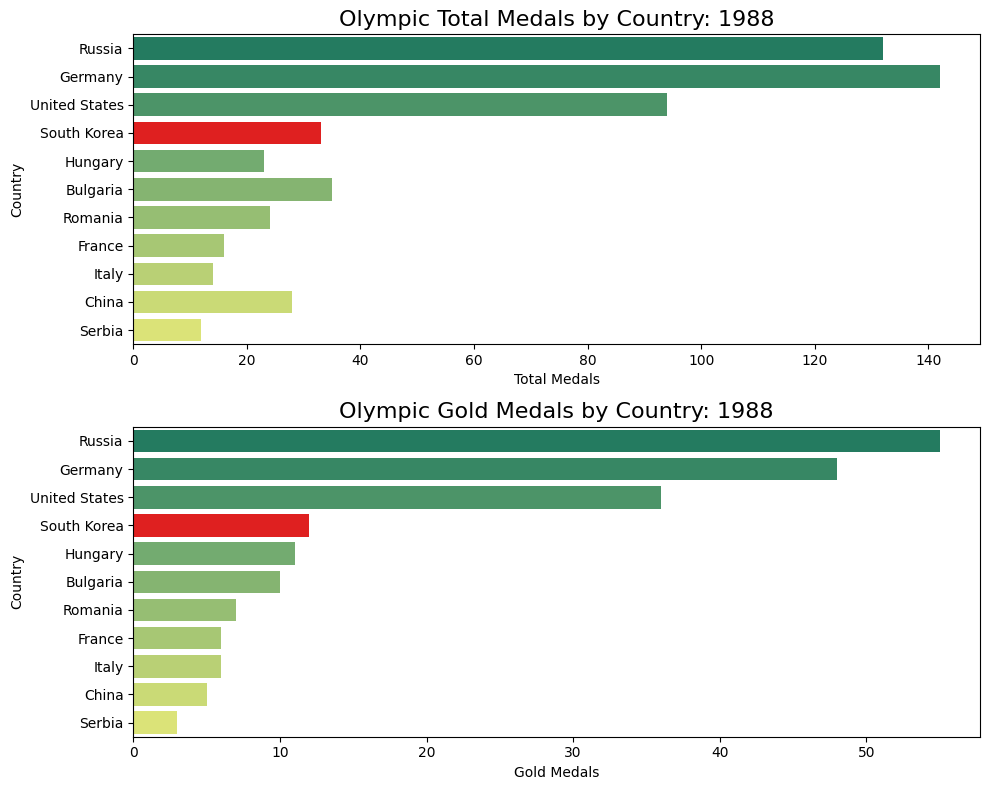

In [ ]:
analiza_medalja_po_godinama(1988, data)

**Tu je i jedna godina kada je Jugoslavija(Srbija kao naslednica) bila u top 10. Deveto mesto 1984.**

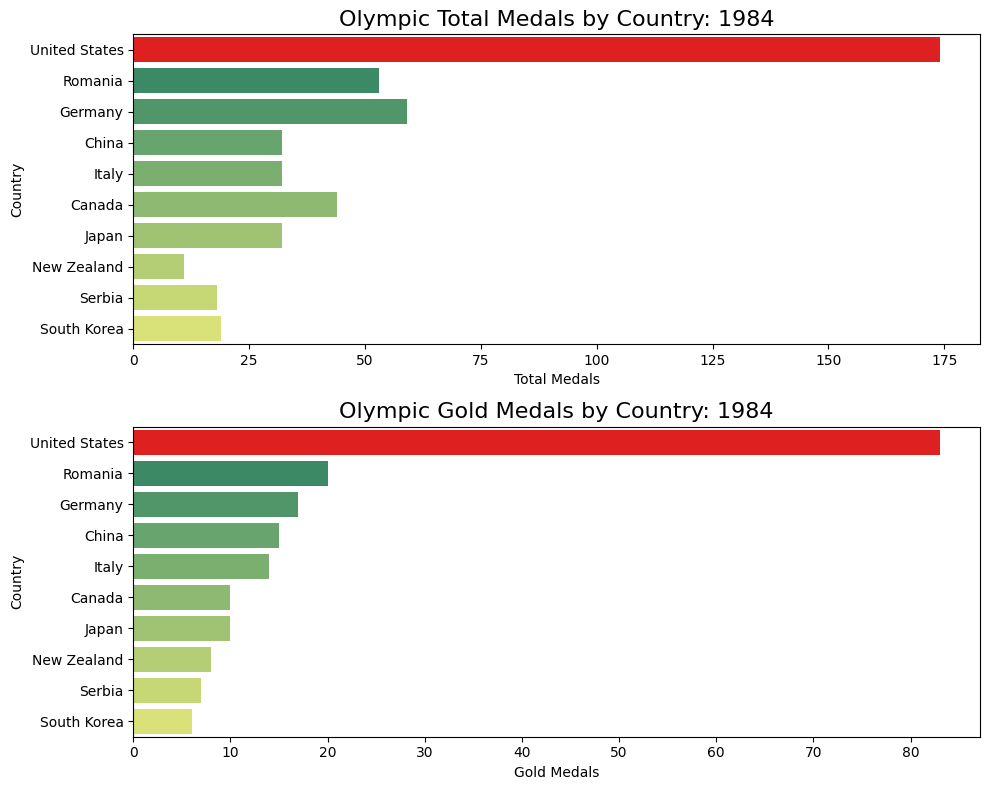

In [ ]:
analiza_medalja_po_godinama(1984, data)

**Sada definisem funkciju koja crta grafik ukupnog broja osvojenih medalja za odabranu zemlju, po godinama.**

In [25]:
def broj_medalja_po_godinama_za_zemlju(country, data):
    # Filtriranje podataka za izabranu zemlju
    country_data = data[data['Country_Name'] == country]

    # Zatim izvlacim sve godine koje se pojavljuju u koloni Year
    all_years = pd.Series(data['Year'].unique())

    # Grupisem podatke po godinama i za svaku zemlju izvlacim ukupan broj medalja po godinama
    total_medals_per_year = data.groupby('Year')[['Total']].sum()

    # Izvlacim podatke za posmatranu zemlju po godinama
    yearly_summary = country_data.groupby('Year')[['Gold', 'Silver', 'Bronze', 'Total']].sum()

    # Dodavanje nula za godine kada zemlja nije imala medalje
    yearly_summary = yearly_summary.reindex(all_years, fill_value=0)

    # Standardizacija - deljenje broja medalja sa ukupnim brojem medalja za tu godinu
    yearly_summary['Total_Standardized'] = yearly_summary['Total'] / total_medals_per_year.iloc[:, 0]

    # Dodavanje kolone koja označava da li je zemlja bila domacin te godine
    yearly_summary['Host'] = yearly_summary.index.isin(data[data['Host_country'] == country]['Year']) # Tacno samo u slucaju da se godine poklope

    # Pretvaranje kolone 'Host' u string vrednosti
    yearly_summary['Host'] = yearly_summary['Host'].map({True: 'Host', False: 'Non-Host'})

    # Kreiranje grafika
    plt.figure(figsize=(12, 6))
    # Posebno crvena boja za godine domacinstva
    sns.barplot(x=yearly_summary.index, y='Total_Standardized', hue='Host', data=yearly_summary,
                palette={'Host': 'red', 'Non-Host': 'skyblue'}, dodge=False)

    plt.title(f'Total Standardized Medals by Year for {country}', fontsize=16)
    plt.xlabel('Year')
    plt.ylabel('Total Standardized Medals')

    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Hosting Status')
    plt.show()



**Ovde posmatramo kako izgleda ucinak pojedinih zemalja koje su bile domacini OI i njihov ucinak u godinama kada su bili domacini i kada nisu.**
**Ono sto sam ovde koristio jeste standardizacija podataka, tako sto sam sabrao sve medalje na tim OI, a zatim ucinak zemlje posmatrao kao kolicnik broja osvojenih medalja i ukupnog broja medalja na tim igrama.**
**Ovo smatram za dobar izbor obzirom da ni broj sportova niti ucesnika nije bio isti kroz godine.**

**Za pocetak sam funkciju primenio na nasu zemlju, a zatim i na neke od zemalja koje su bile organizator OI**

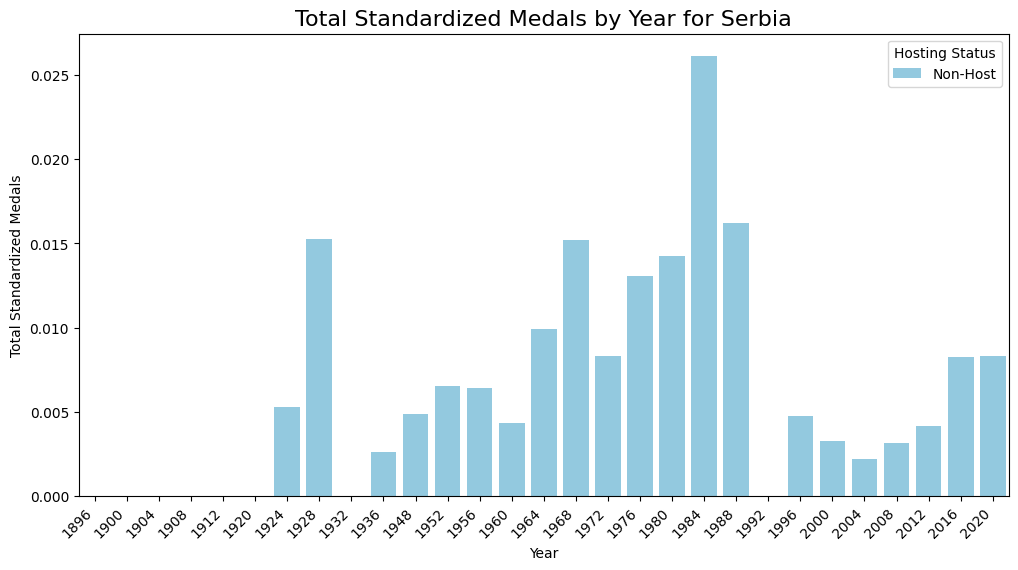

In [26]:
broj_medalja_po_godinama_za_zemlju('Serbia', data)

**Najpre su tu oni prvi primeri, kada je domacinstvo donosilo visestruko vise medalja u odnosu na godine kada zemlje nije domacin.**

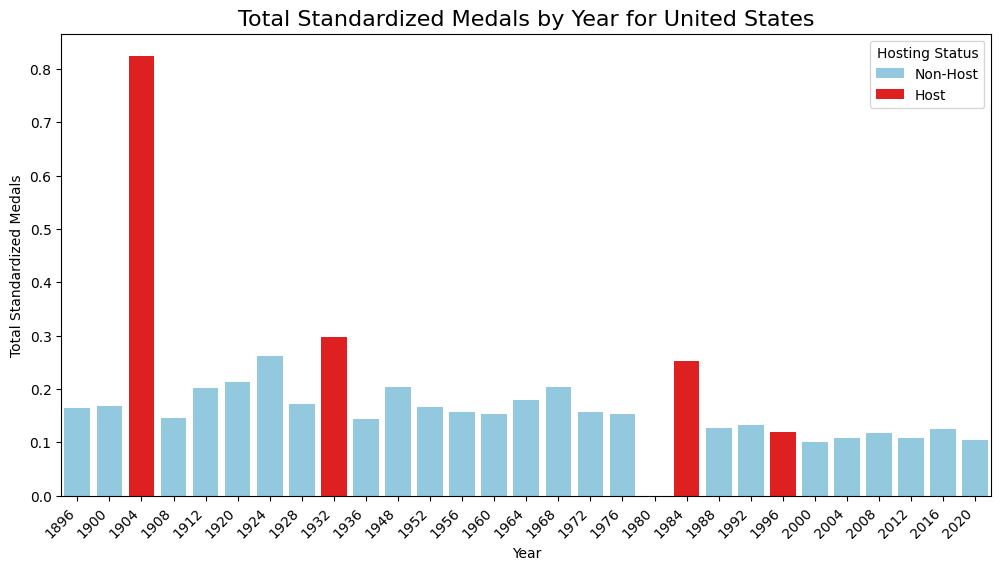

In [27]:
broj_medalja_po_godinama_za_zemlju('United States', data)

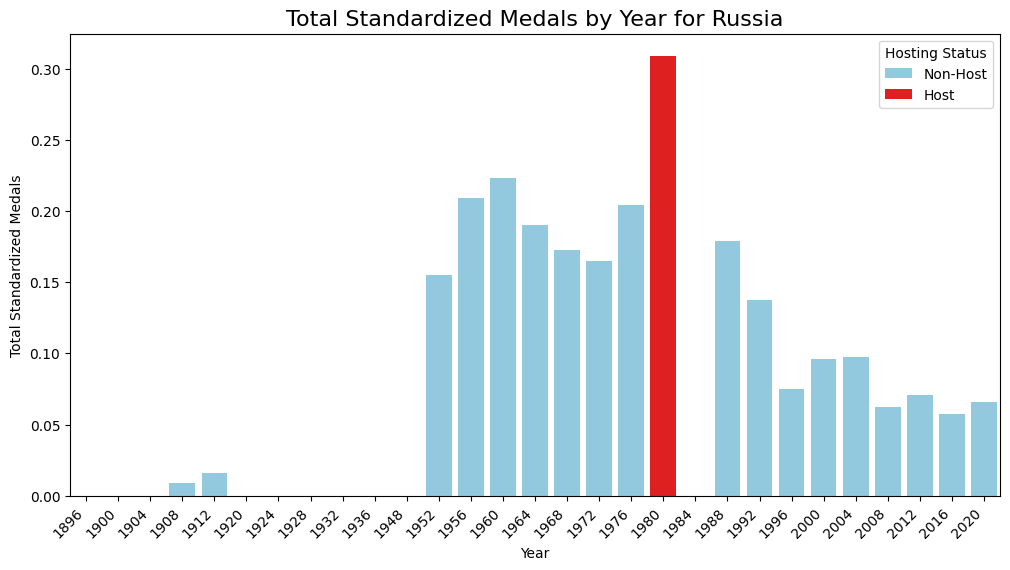

In [ ]:
broj_medalja_po_godinama_za_zemlju('Russia', data)

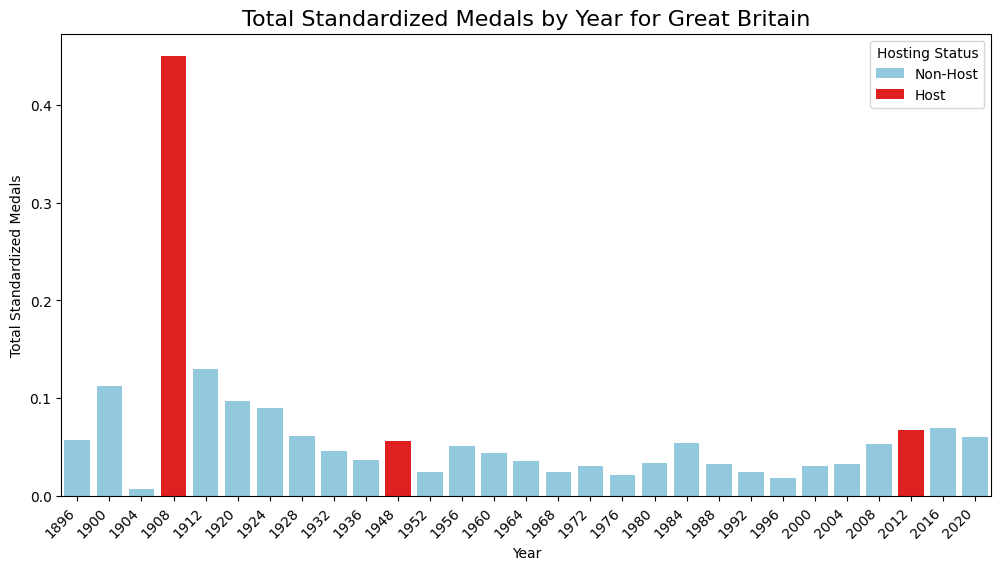

In [ ]:
broj_medalja_po_godinama_za_zemlju('Great Britain', data)

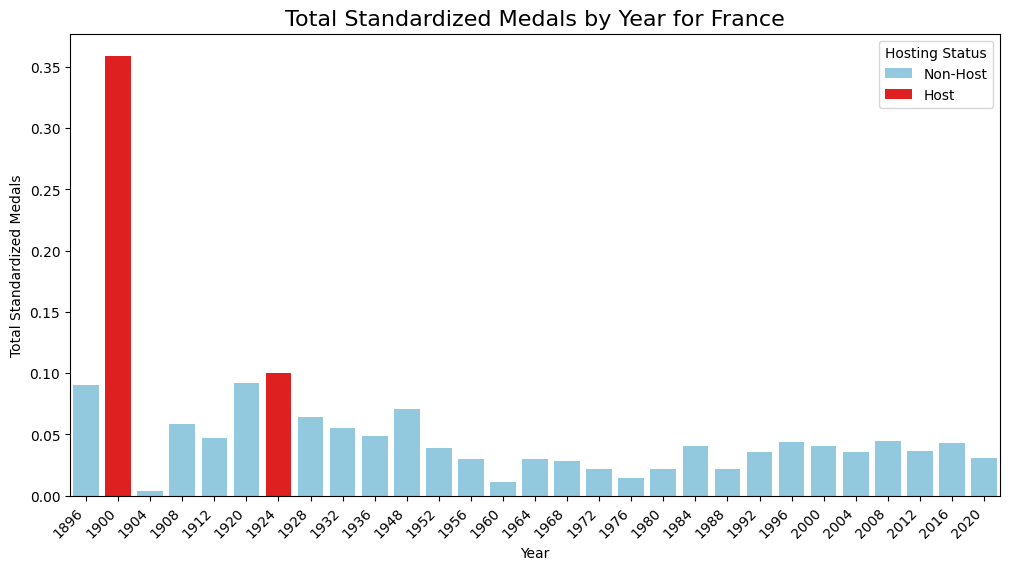

In [ ]:
broj_medalja_po_godinama_za_zemlju('France', data)

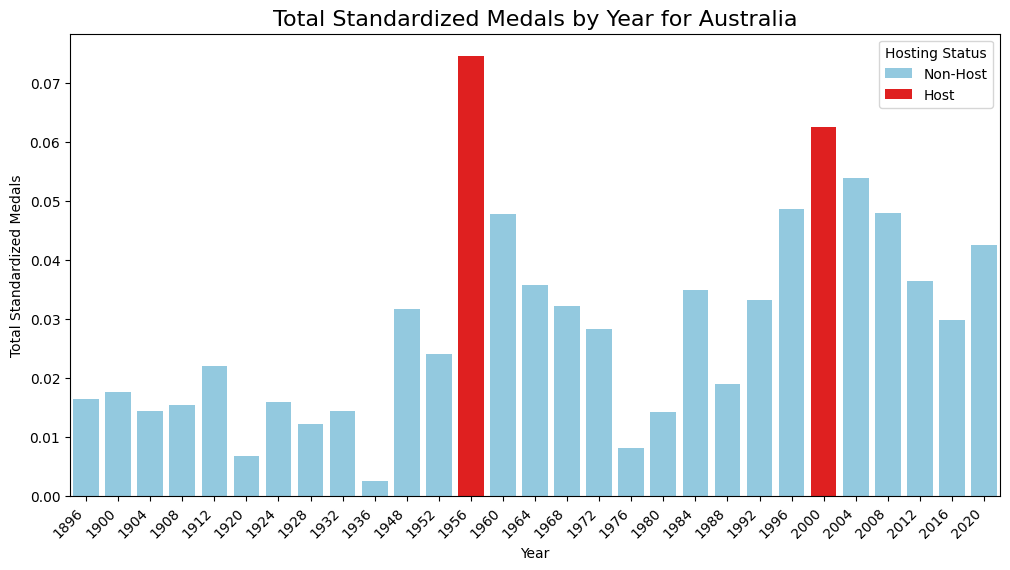

In [ ]:
broj_medalja_po_godinama_za_zemlju('Australia', data)

**Kod Nemacke primetimo veliki skok u prvoj godini organizovanja i ponovo skok u godini druge organizacije, ali on ostaje pomalo zanemaren na ovom grafiku obzirom na to da Nemacka kao naslednik Istocne i Zapadne Nemacke u godinama nakon organizacije ima jos veci broj medalja(sabiranjem medalja tada dve razlicite zemlje).**

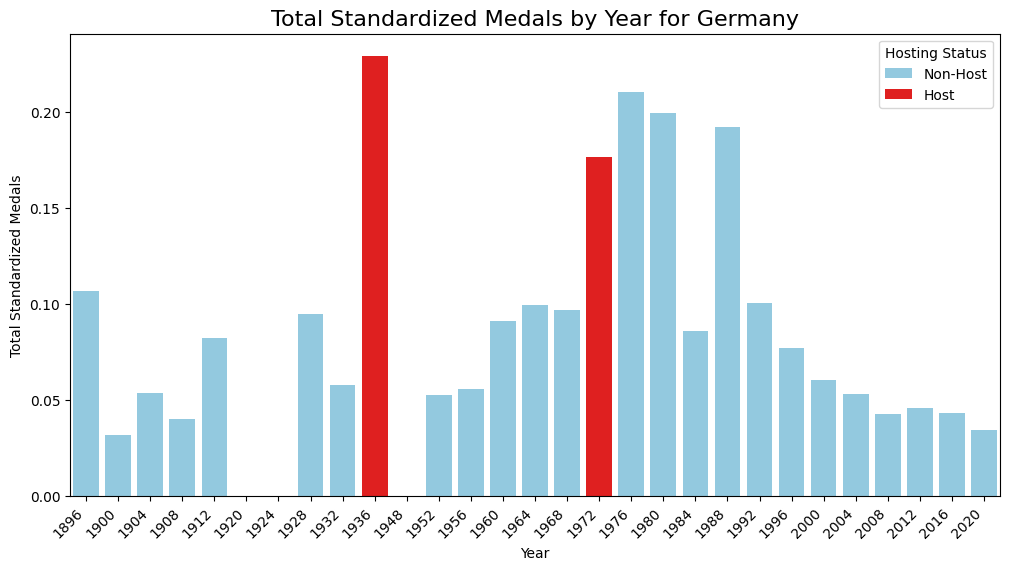

In [ ]:
broj_medalja_po_godinama_za_zemlju('Germany', data)

**Kina je zanimljiva sa strane toga da se pojavila kao osvajac tek 1984.**

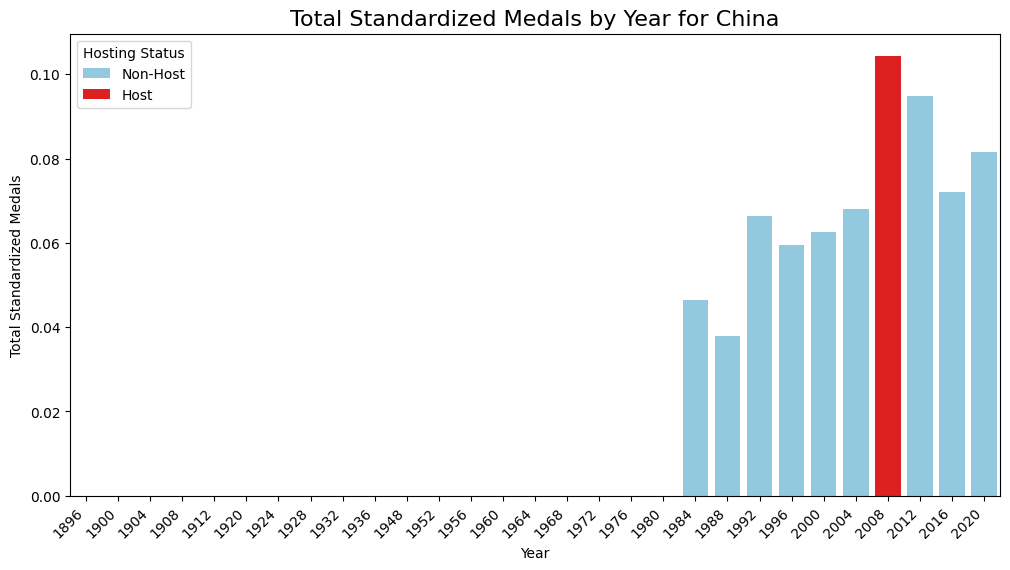

In [ ]:
broj_medalja_po_godinama_za_zemlju('China', data)

**Tu je i Japan koji ima najveci procenat osvojenih medalja u dve godine kada je bio domacin, ali to nisu jako veliki skokovi.**

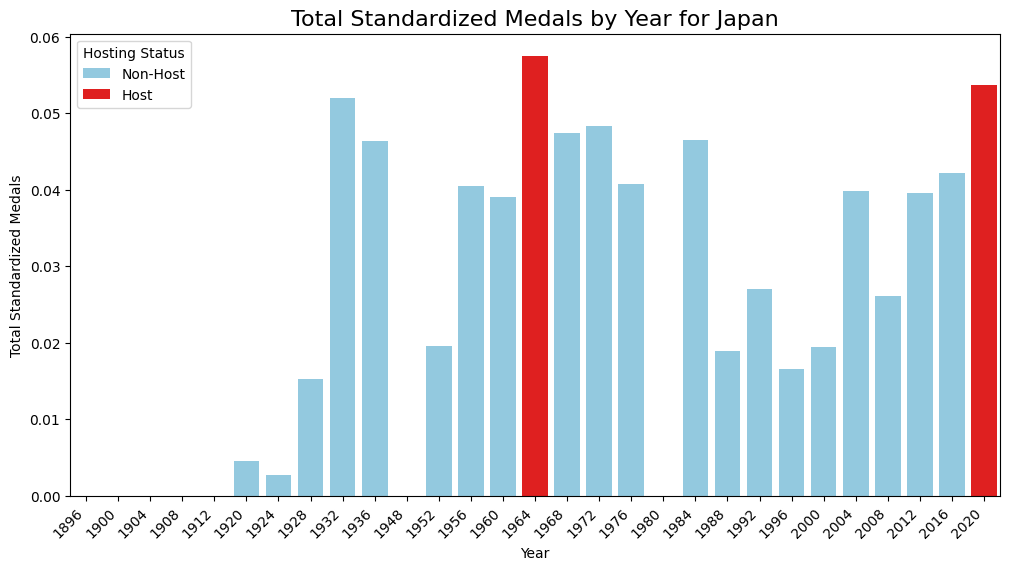

In [ ]:
broj_medalja_po_godinama_za_zemlju('Japan', data)

**Redak je slucaj da zemlje imaju manji broj medalja u godinama organizacije, takav slucaj je sa Finskom koja je imala veci broj medalja u gotovu svim godinama koje su prethodile organizaciji, dok se nakon organizovanja vidi osetan pad, nakon koga se vise nikada nisu vratili na taj nivo.**

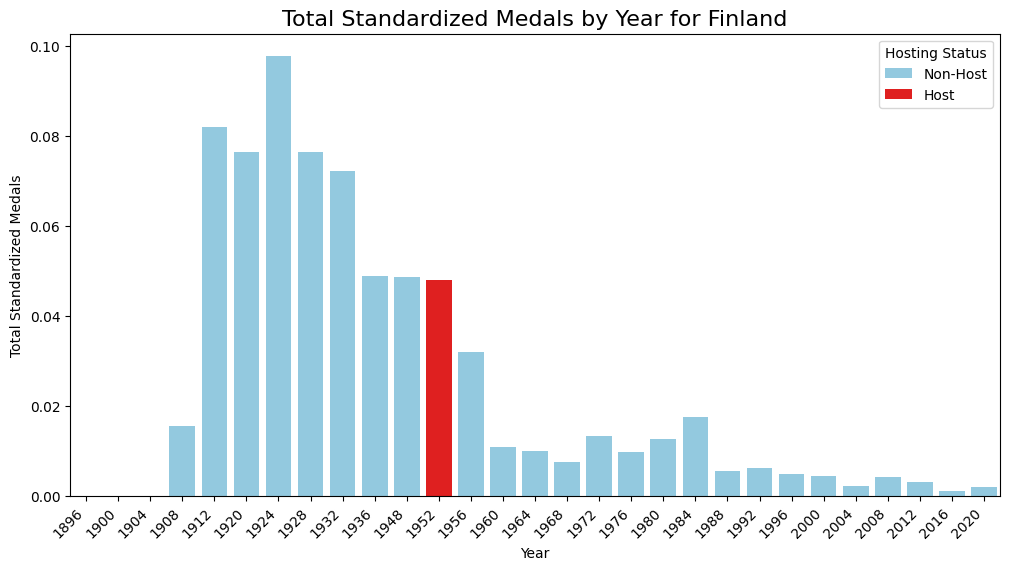

In [ ]:
broj_medalja_po_godinama_za_zemlju('Finland', data)

**Ali i potpuno drugaciji primer Spanije koja u godini organizacije, ali i kasnijim godinama belezi daleko bolje rezultate u odnosu na period pre organizacije.**

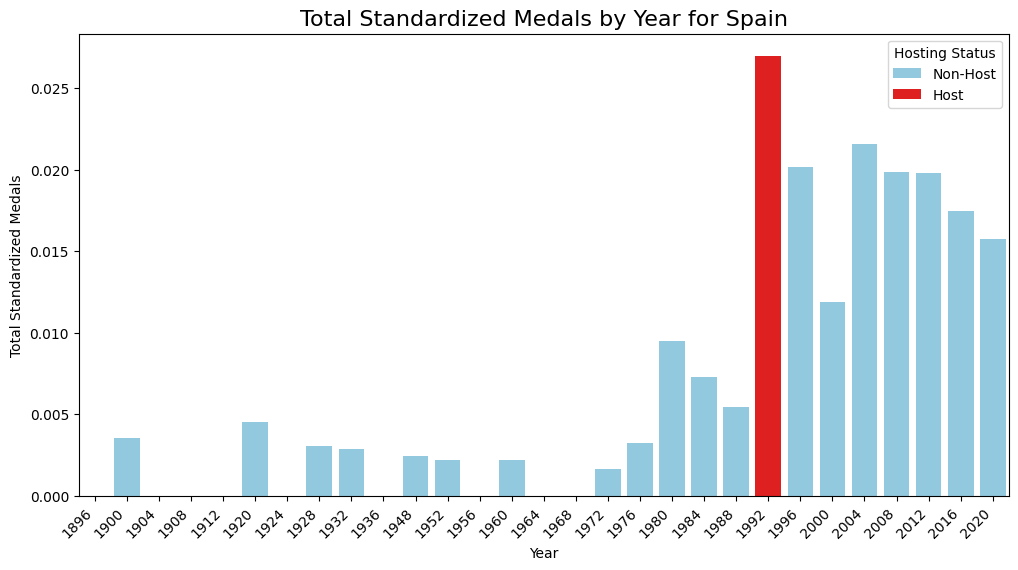

In [ ]:
broj_medalja_po_godinama_za_zemlju('Spain', data)

**Da organizacija ne znaci uvek i veci broj medalja pokazuje Kanada, koja je jedan od najlosijih rezultata zabelezila bas u godini kada je bila organizator.**

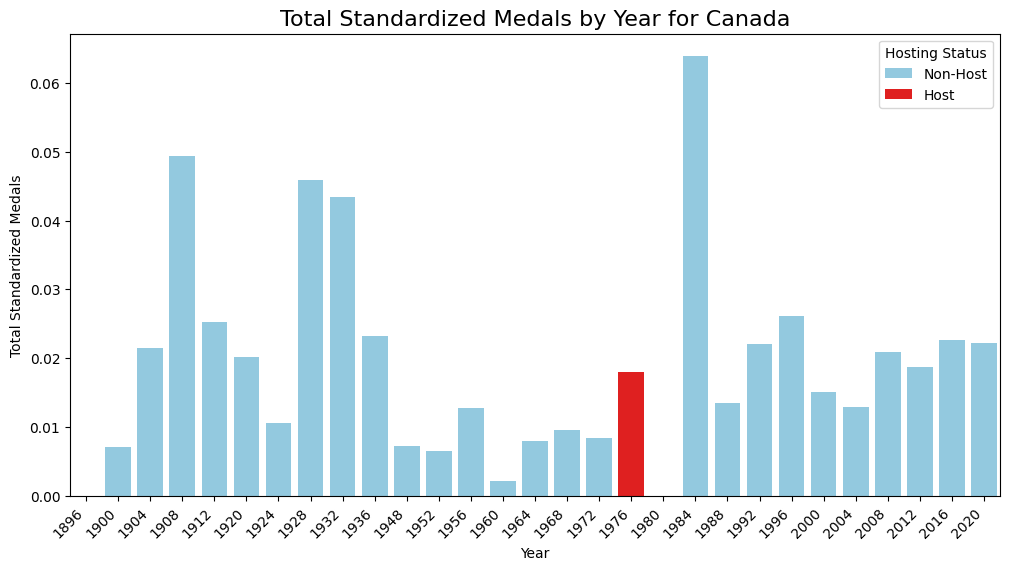

In [ ]:
broj_medalja_po_godinama_za_zemlju('Canada', data)

**Ovde sam odradio prosek broja osvojenih medalja u godinama organizacije i u godinama kada drzava nije bila organizator.**

     Country_Name  Avg_Medals_Host  Avg_Medals_Non_Host        Diff
0          Greece            31.50             3.222222   28.277778
1          France            70.00            22.666667   47.333333
2   United States           152.25            84.208333   68.041667
3   Great Britain            78.00            26.307692   51.692308
4          Sweden            65.00            16.846154   48.153846
5         Belgium            42.00             4.840000   37.160000
6     Netherlands            19.00            12.120000    6.880000
7         Germany            97.50            49.666667   47.833333
8         Finland            22.00            11.320000   10.680000
9       Australia            46.50            17.259259   29.240741
10          Italy            36.00            22.461538   13.538462
11          Japan            43.50            20.500000   23.000000
12         Mexico             9.00             3.150000    5.850000
13         Canada            11.00            12

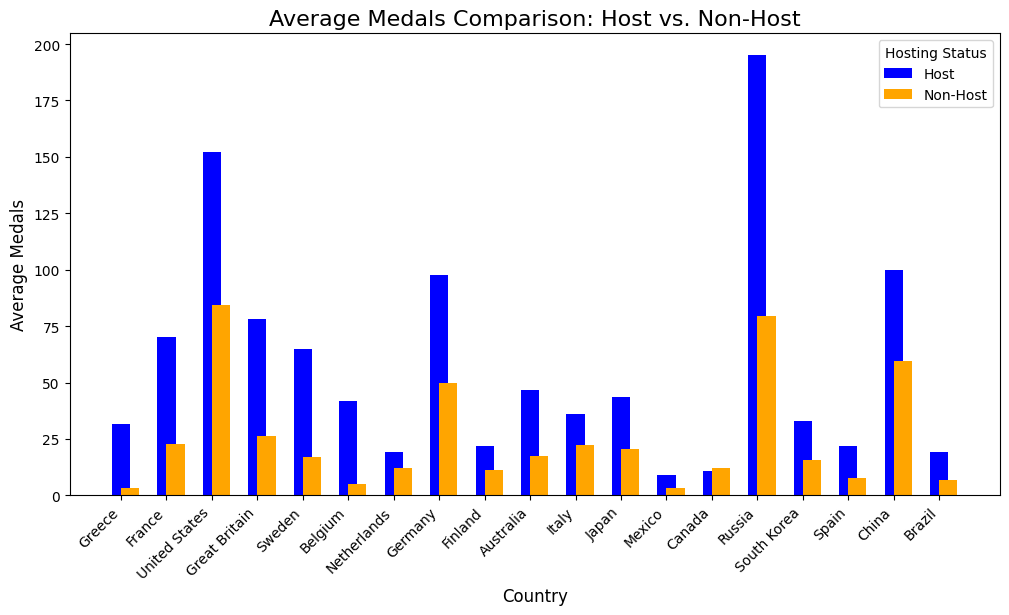

In [28]:
# Kreiram prazan DataFrame za cuvanje rezultata
results = pd.DataFrame(columns=['Country_Name', 'Avg_Medals_Host', 'Avg_Medals_Non_Host'])

# Prazna lista za prikupljanje novih redova
rows = []

# Iteracija kroz sve zemlje u skupu Domacini
for country in Domacini:
    # Podaci za zemlju kada je bila domacin
    host_years = data[(data['Country_Name'] == country) & (data['Country_Name'] == data['Host_country'])]

    # Podaci za zemlju kada nije bila domacin
    non_host_years = data[(data['Country_Name'] == country) & (data['Country_Name'] != data['Host_country'])]

    # Broj godina kada je zemlja bila domacin
    num_host_years = host_years['Year'].nunique()

    # Broj godina kada zemlja nije bila domacin, a osvajala je medalje
    num_non_host_years = non_host_years['Year'].nunique()

    # Ukupan broj medalja zemlje kada je bila domacin
    total_medals_host = host_years[['Gold', 'Silver', 'Bronze']].sum().sum()

    # Ukupan broj medalja kada zemlja nije bila domacin
    total_medals_non_host = non_host_years[['Gold', 'Silver', 'Bronze']].sum().sum()


    # Izracunavanje proseka medalja u godinama domacinstva i svim ostalim
    avg_medals_host = total_medals_host / num_host_years if num_host_years > 0 else 0
    avg_medals_non_host = total_medals_non_host / num_non_host_years if num_non_host_years > 0 else 0

    # I sada dodajem dobijene rezultate u DataFrame
    rows.append({
        'Country_Name': country,
        'Avg_Medals_Host': avg_medals_host,
        'Avg_Medals_Non_Host': avg_medals_non_host
    })

# Kreiranje DataFrame-a iz liste rows
results = pd.DataFrame(rows)
results['Diff'] = results['Avg_Medals_Host'] - results['Avg_Medals_Non_Host']  # Racunanje razlike u godinama domacinstva i inace
print(results)

# Crtanje grafika
plt.figure(figsize=(12, 6))
plt.bar(results['Country_Name'], results['Avg_Medals_Host'], color='blue', width=0.4, label='Host', align='center')
plt.bar(results['Country_Name'], results['Avg_Medals_Non_Host'], color='orange', width=0.4, label='Non-Host', align='edge')

plt.title('Average Medals Comparison: Host vs. Non-Host', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Average Medals', fontsize=12)

plt.legend(title='Hosting Status')
plt.xticks(rotation=45, ha='right')
plt.show()

**Sada izvlacim na koliko Olimpijada su zemlje iz top10 i Srbija osvajale medalje.**

In [29]:
Ukupan_ucinak_sortirano = data.groupby('Country_Name').sum().sort_values(by=['Gold', 'Silver', 'Bronze'], ascending=False)
top_10 = Ukupan_ucinak_sortirano.head(10)
serbia = Ukupan_ucinak_sortirano.loc[['Serbia']]

# Kombinovanje top 10 zemalja i Srbije
final_selection = pd.concat([top_10, serbia])

def broj_ucesca_sa_medaljama(country):
    # Brojim koliko puta se posmatrana zemlje pojavljuje u koloni gde su osvajaci medalja
    counts = data[data['Country_Name'] == country].shape[0]
    print(f"{country} je na {counts} Olimpijada osvajala medalje.")
    print()  # Ovaj print je tu kako bi se nakon svakog ispisa pravio red razmaka

# Iteracija kroz zemlje iz top10 + Srbija
for country in final_selection.index:
    broj_ucesca_sa_medaljama(country)

United States je na 28 Olimpijada osvajala medalje.

Russia je na 19 Olimpijada osvajala medalje.

Germany je na 30 Olimpijada osvajala medalje.

Great Britain je na 29 Olimpijada osvajala medalje.

China je na 10 Olimpijada osvajala medalje.

France je na 29 Olimpijada osvajala medalje.

Italy je na 27 Olimpijada osvajala medalje.

Hungary je na 27 Olimpijada osvajala medalje.

Japan je na 22 Olimpijada osvajala medalje.

Australia je na 29 Olimpijada osvajala medalje.

Serbia je na 21 Olimpijada osvajala medalje.



**Ovde izvlacim procenat osvojenih medalja od strane organizatora za svaku godinu.**
**Zakljucak koji moze da se izvuce je da su u pocetnim godinama daleko veci procenat medalja uzimali domacini, dok je u novije vreme to daleko manja prednost.**

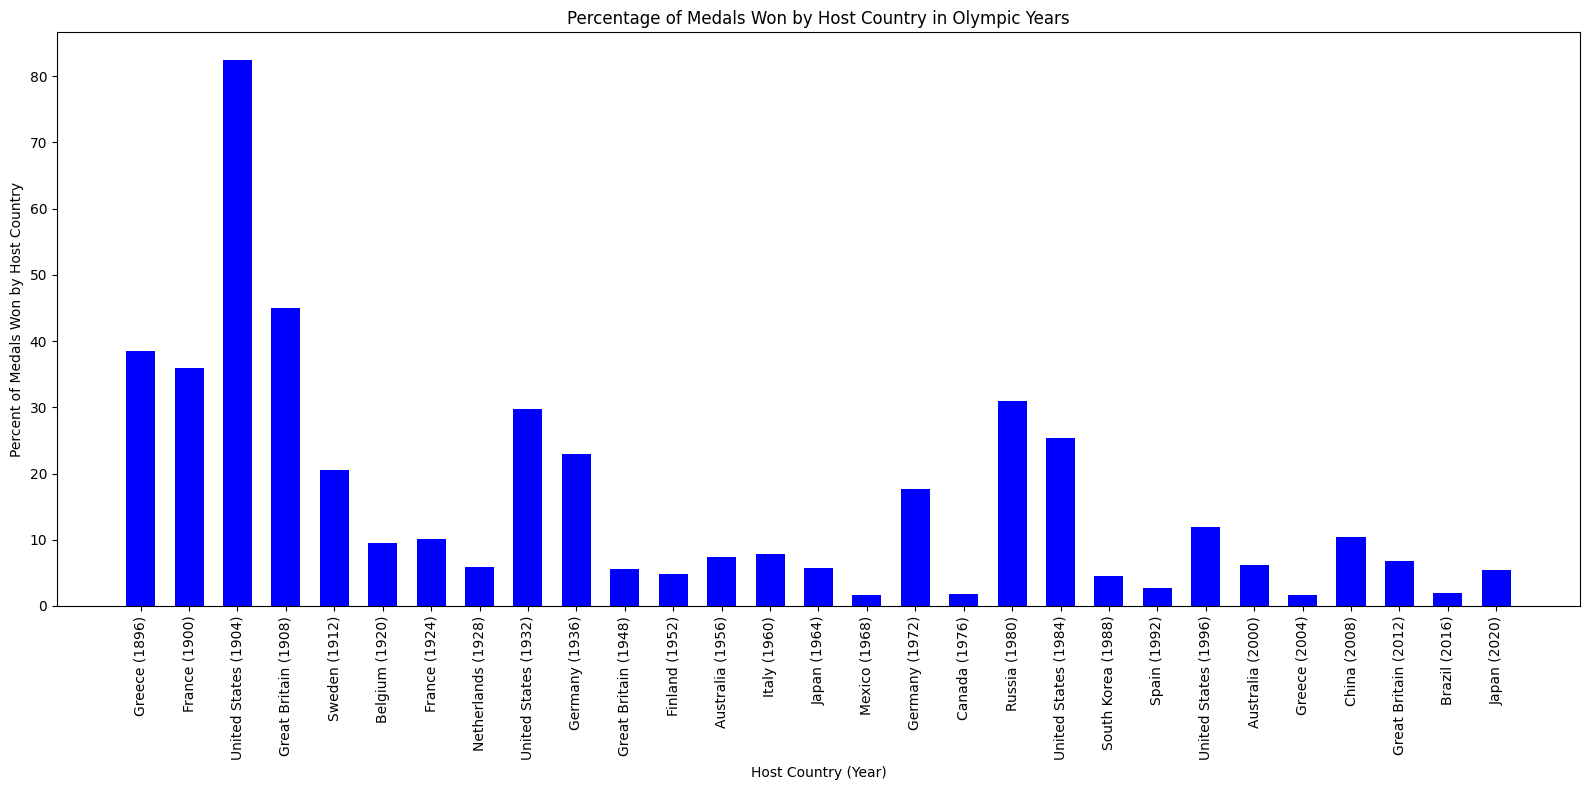

In [30]:
# Kreiram listu
procenti = []

# Iteracija kroz svaku godinu i zemlju domacina
for _, row in data.iterrows():
    country = row['Host_country']
    year = row['Year']

    # Podaci za posmatranu godinu i domacina te godine
    country_data = data[(data['Country_Name'] == country) & (data['Year'] == year)]
    total_medals_host = country_data[['Gold', 'Silver', 'Bronze']].sum().sum()

    # Ukupan broj medalja za tu godinu
    total_medals_year = data[data['Year'] == year][['Gold', 'Silver', 'Bronze']].sum().sum()

    # Izracunavanje procenta osvojenih medalja
    percent_medals_host = (total_medals_host / total_medals_year) * 100

    # Dodavanje rezultata u listu
    procenti.append({'Country_Name': country, 'Year': year, 'Percent_Medals_Host': percent_medals_host})

# Kreiram DataFrame od liste
procenti_df = pd.DataFrame(procenti)

# Kombinovanje godine i imena zemlje za oznake na x-osi
procenti_df['Label'] = procenti_df['Country_Name'] + ' (' + procenti_df['Year'].astype(str) + ')'

# Kreiranje grafika
plt.figure(figsize=(16, 8))
plt.bar(procenti_df['Label'], procenti_df['Percent_Medals_Host'], color='blue', width=0.6)
plt.xlabel('Host Country (Year)')
plt.ylabel('Percent of Medals Won by Host Country')
plt.title('Percentage of Medals Won by Host Country in Olympic Years')
plt.xticks(rotation=90)  # Jedini nacin da bude lepo citljivo
plt.tight_layout()
plt.show()

**Sada sabiram broj osvojenih medalja u svakoj godini OI i vidimo kako broj medalja uglavnom raste, a to je zbog povecanog broja sportova, disciplina, ali i nacina dodele medalja(u pojedinim sportovima, uglavnom borilackim se dele po dve bronzane medalje od kraja proslog veka).**

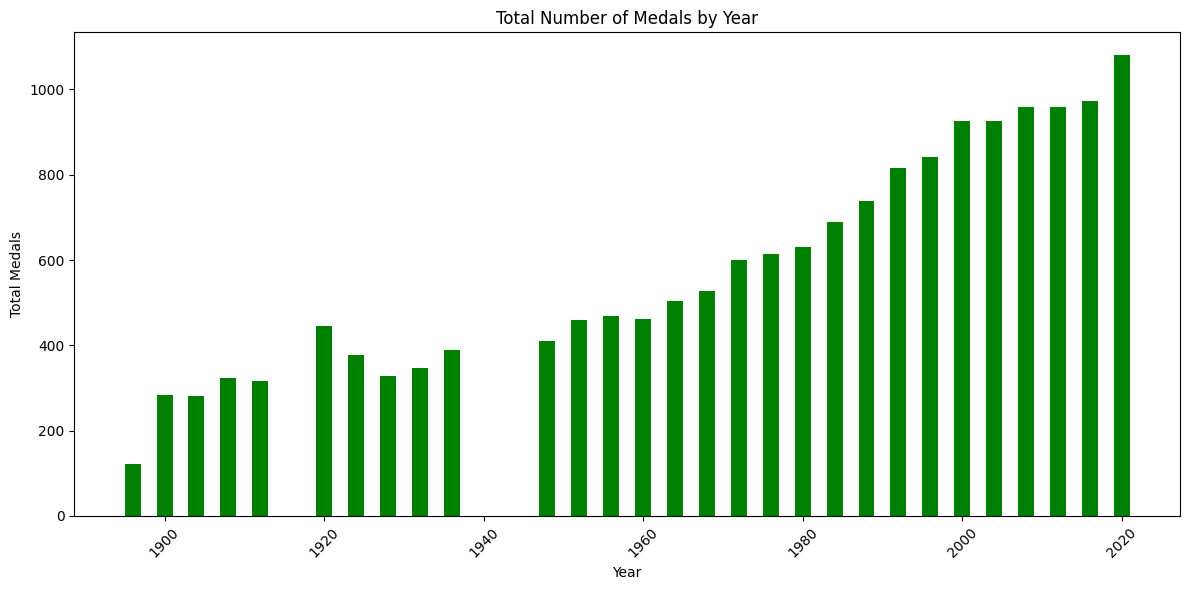

In [31]:
# Grupisem podatke po godinama
total_medals_per_year = data.groupby('Year')[['Total']].sum()

# Kreiram grafik
plt.figure(figsize=(12, 6))
plt.bar(total_medals_per_year.index, total_medals_per_year['Total'], color='green', width=2)
plt.xlabel('Year')
plt.ylabel('Total Medals')
plt.title('Total Number of Medals by Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Sada radim slicnu analizu kao u nekom od prethodnih slucajeva, samo sada prikazujem posebno zlatne, srebrne i bronzane medalje na grafiku.**

In [32]:
def broj_medalja_po_vrstama(country, data):
    # Prvo biram samo podatke za izabranu zemlju
    country_data = data[data['Country_Name'] == country]

    # Dodajem i upozorenje ukoliko je uneta nepostojeca zemlja
    if country_data.empty:
        print(f"Nema podataka za {country}.")
        return

    # Ponovo grupisem podatke za posmatranu zemlju po godinama
    yearly_summary = country_data.groupby('Year')[['Gold', 'Silver', 'Bronze']].sum()

    # Prilagodjavam podatke za prikaz u seaborn-u
    yearly_summary = yearly_summary.reset_index().melt(id_vars='Year', value_vars=['Gold', 'Silver', 'Bronze'],
                                                       var_name='Medal_Type', value_name='Medal_Count')

    # Kreiram grafik
    plt.figure(figsize=(16, 8))
    sns.barplot(x='Year', y='Medal_Count', hue='Medal_Type', data=yearly_summary,
                palette={'Gold': 'gold', 'Silver': 'silver', 'Bronze': '#cd7f32'}, dodge=True)

    plt.title(f'Medals by Year for {country}', fontsize=16)
    plt.xlabel('Year')
    plt.ylabel('Number of Medals')

    plt.xticks(rotation=45, ha='right')
    plt.show()

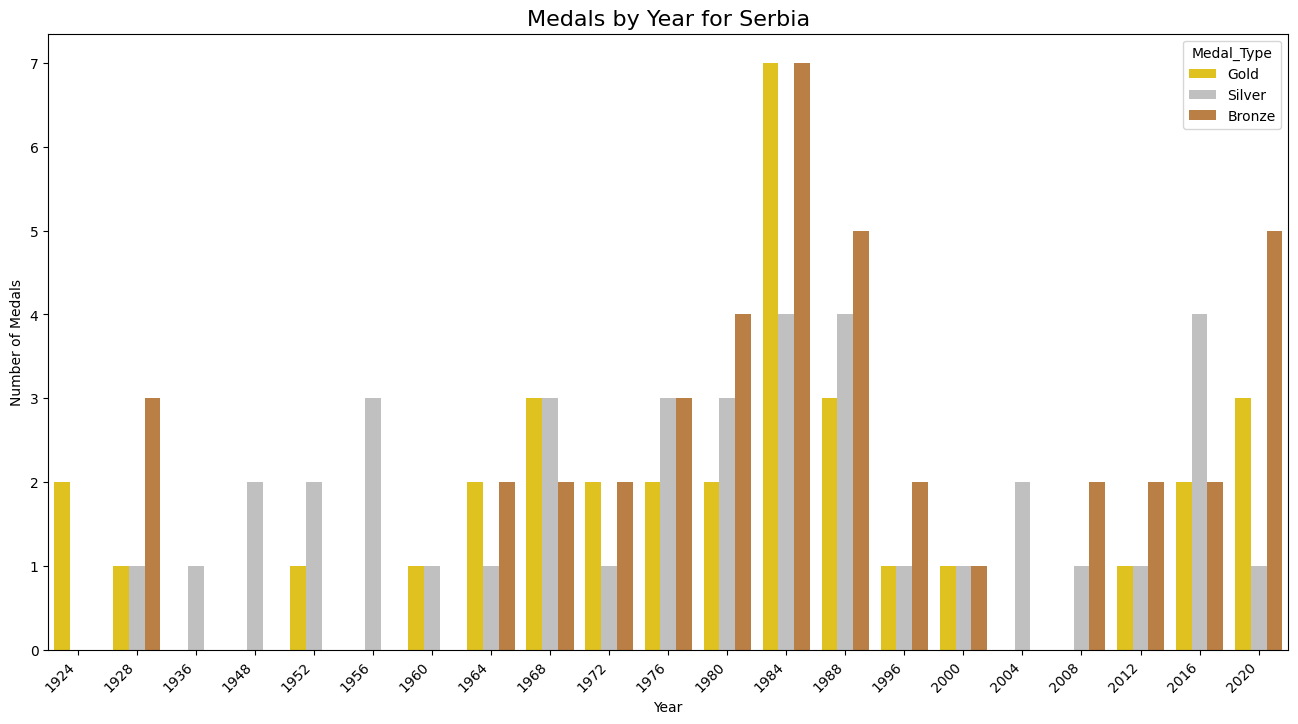

In [33]:
broj_medalja_po_vrstama('Serbia', data)

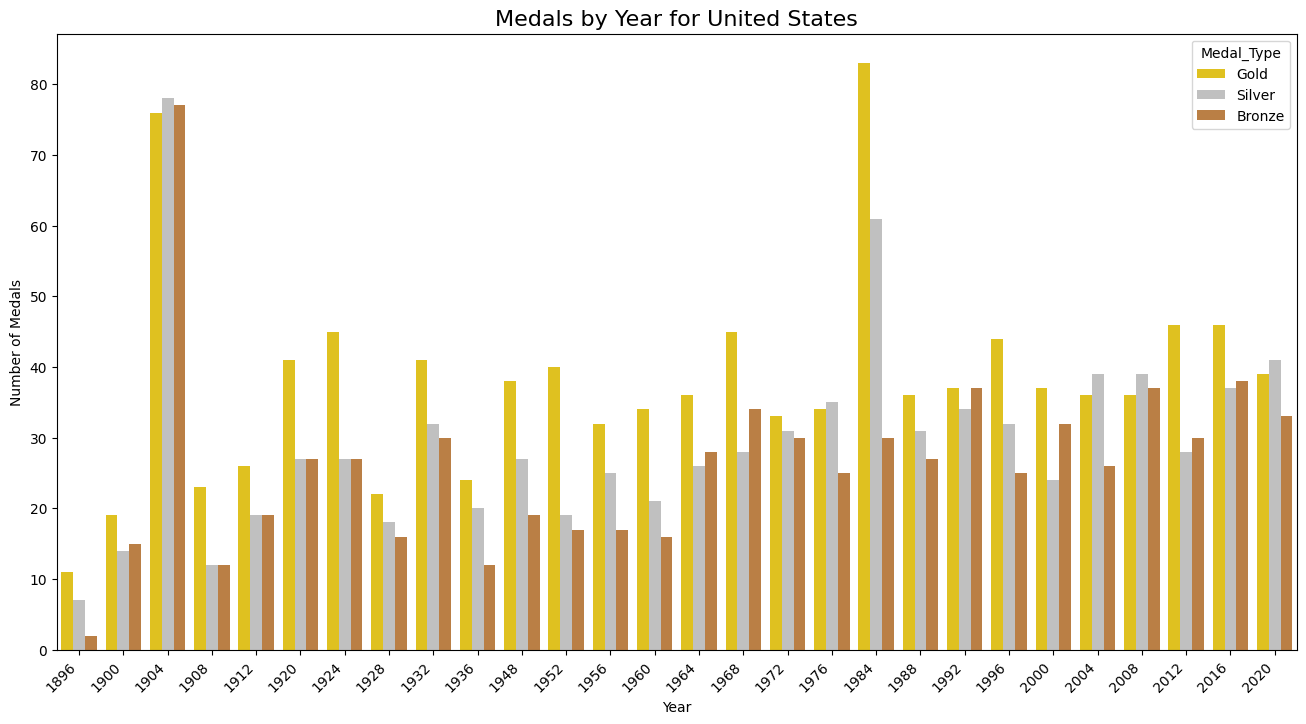

In [34]:
broj_medalja_po_vrstama('United States', data)

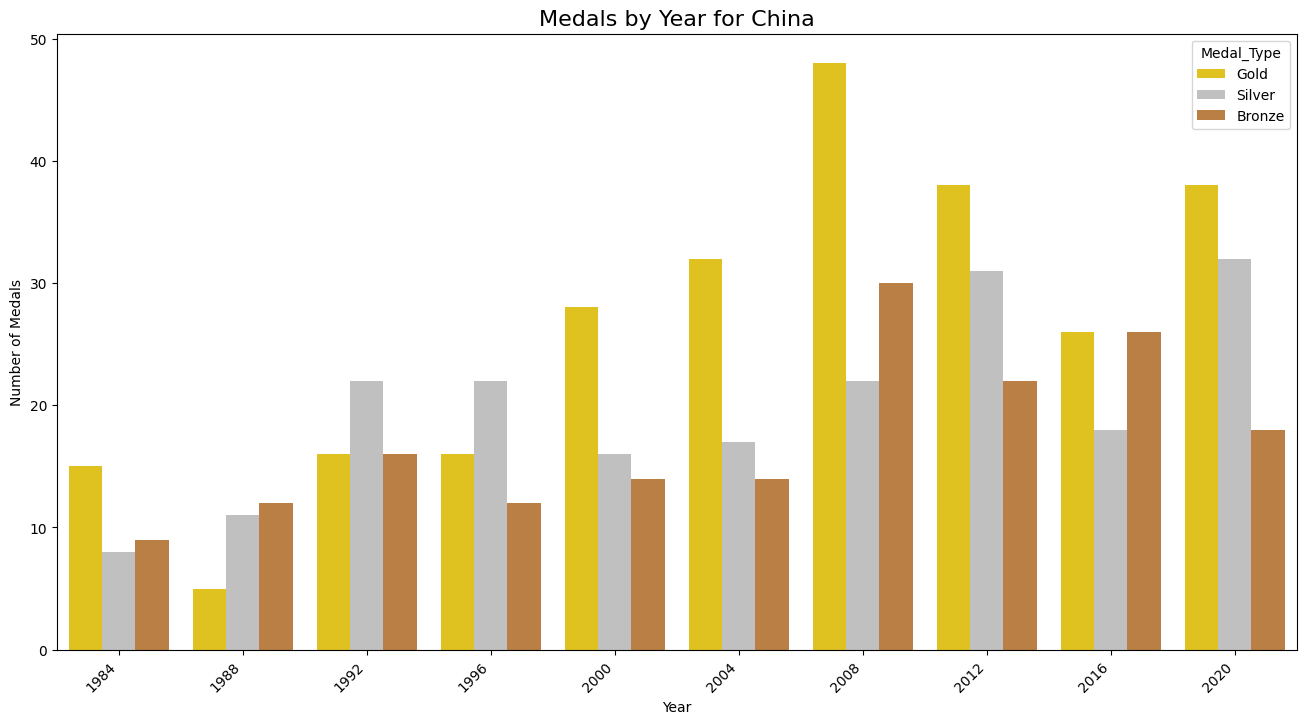

In [ ]:
broj_medalja_po_vrstama('China', data)

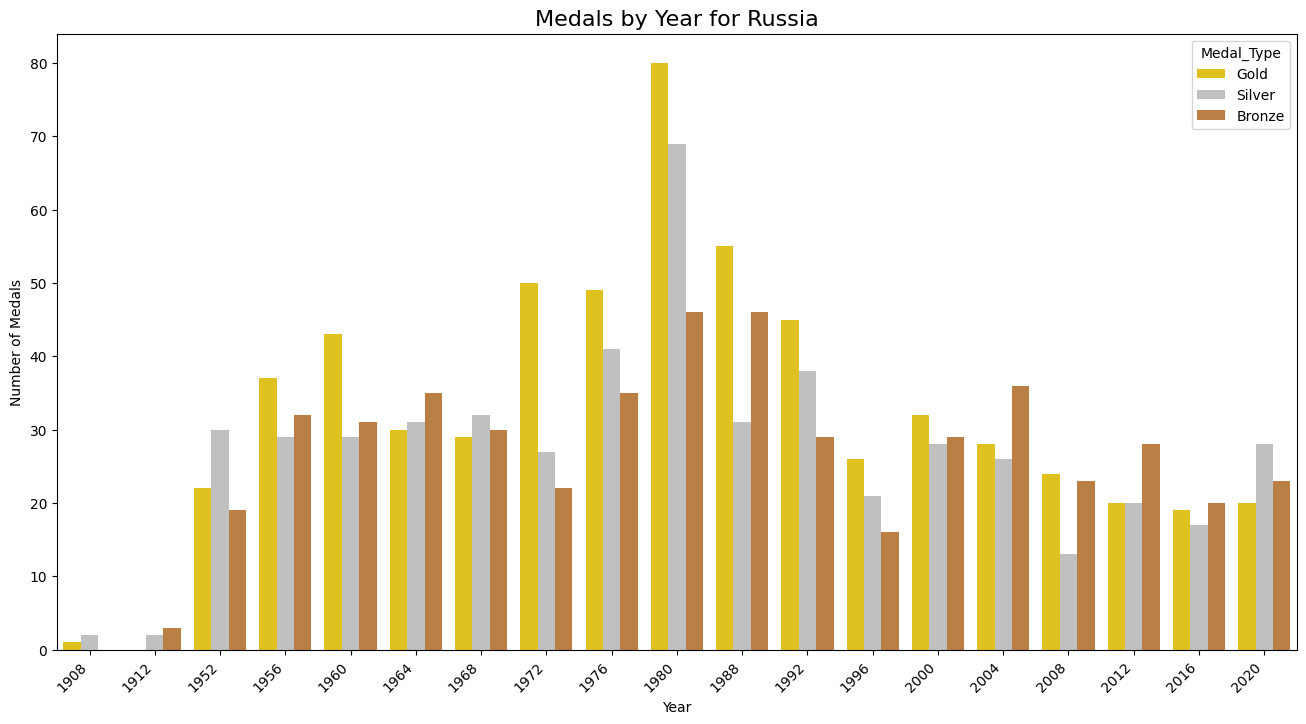

In [ ]:
broj_medalja_po_vrstama('Russia', data)

**Sada sam odredio udeo svake od medalja po godinama za odabranu zemlju.**

In [35]:
def raspodela_po_medaljama(country, data):
    # Uzimam podatke za odabranu zemlju
    country_data = data[data['Country_Name'] == country]

    # Provera da li postoje podaci za izabranu zemlju
    if country_data.empty:
        print(f"No data available for {country}")
        return

    # Grupisanje podataka po godinama
    yearly_summary = country_data.groupby('Year')[['Gold', 'Silver', 'Bronze', 'Total']].sum()

    # Racunanje procenta zlatnih, srebrnih i bronzanih medalja
    yearly_summary['Gold_Percentage'] = yearly_summary['Gold'] / yearly_summary['Total']
    yearly_summary['Silver_Percentage'] = yearly_summary['Silver'] / yearly_summary['Total']
    yearly_summary['Bronze_Percentage'] = yearly_summary['Bronze'] / yearly_summary['Total']

    # Kreiram grafik
    plt.figure(figsize=(14, 8))
    bar_width = 2

    # Najpre postavljam udeo zlatnih, zatim ostavljam zlatne na dnu, pa nadovezujem srebrne i onda slicno i bronzane
    bars_gold = plt.bar(yearly_summary.index, yearly_summary['Gold_Percentage'], color='gold', width=bar_width, label='Gold')
    bars_silver = plt.bar(yearly_summary.index, yearly_summary['Silver_Percentage'], bottom=yearly_summary['Gold_Percentage'], color='silver', width=bar_width, label='Silver')
    bars_bronze = plt.bar(yearly_summary.index, yearly_summary['Bronze_Percentage'], bottom=yearly_summary['Gold_Percentage'] + yearly_summary['Silver_Percentage'], color='#cd7f32', width=bar_width, label='Bronze')

    plt.title(f'Medal Distribution by Year for {country}', fontsize=16)
    plt.xlabel('Year')
    plt.ylabel('Medal Distribution')

    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Medal Type')
    plt.show()

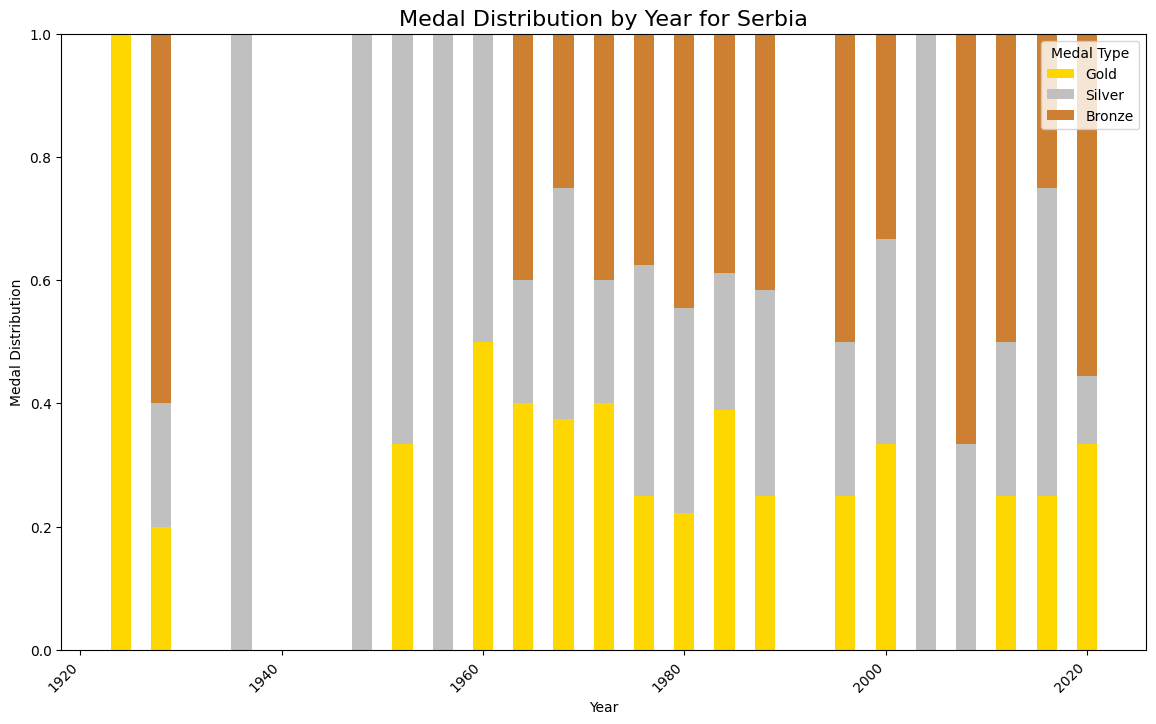

In [36]:
raspodela_po_medaljama('Serbia', data)

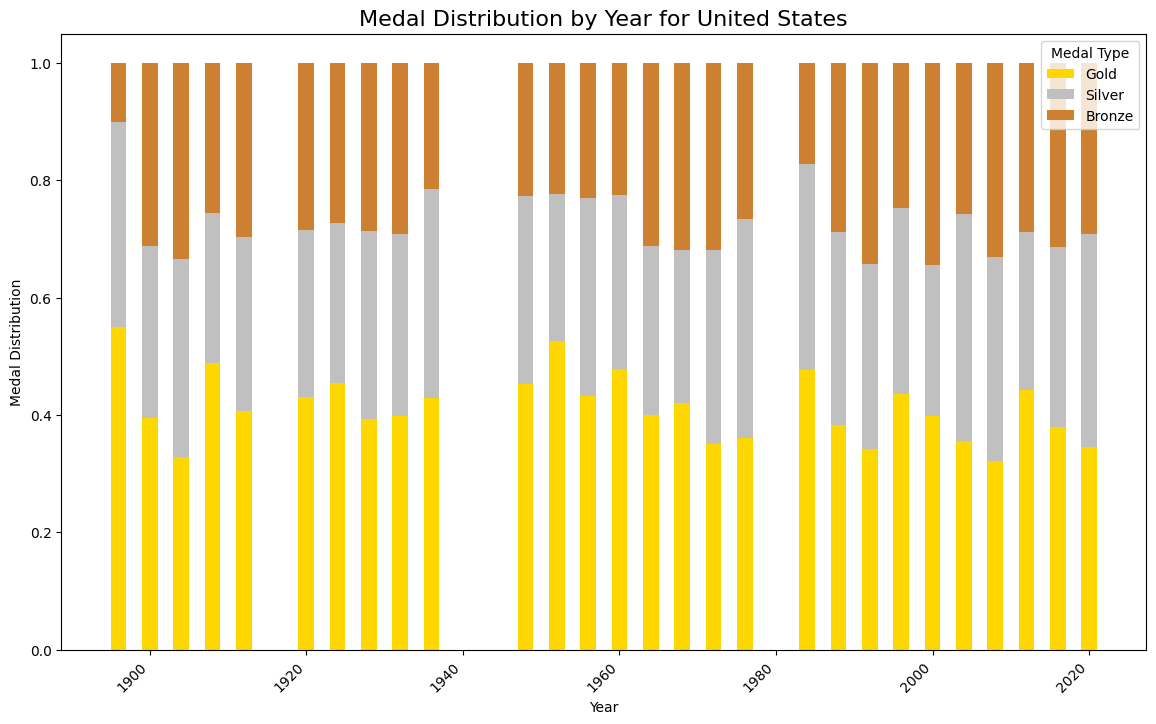

In [37]:
raspodela_po_medaljama('United States', data)

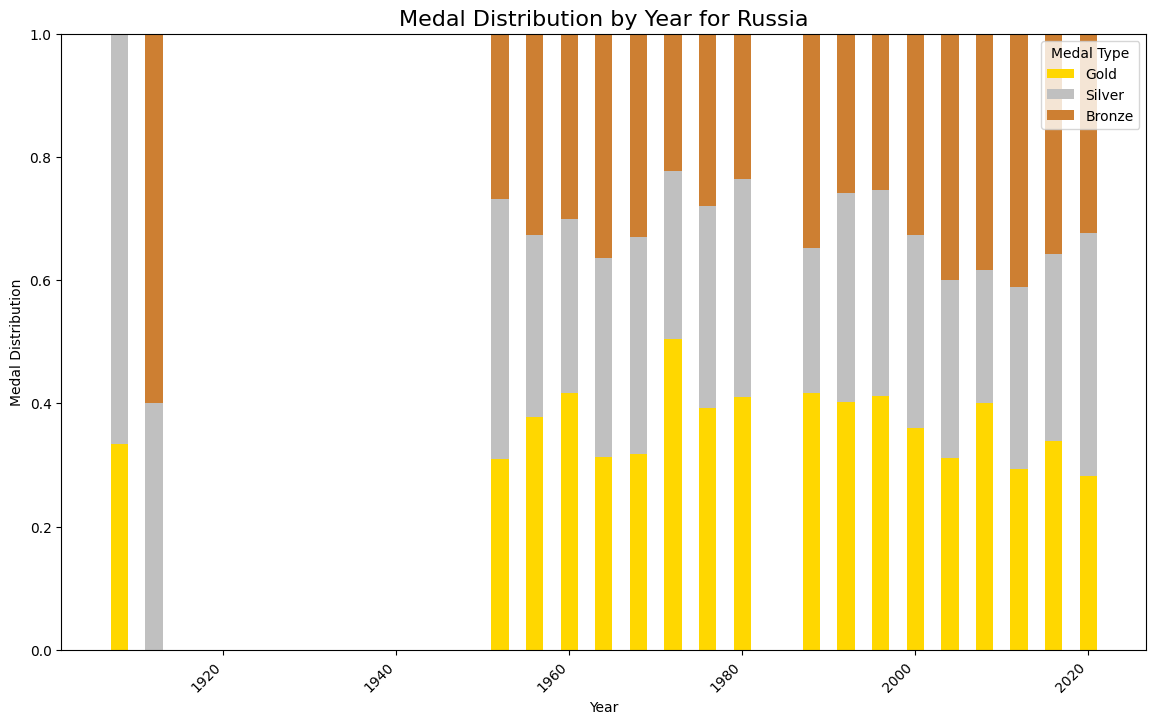

In [ ]:
raspodela_po_medaljama('Russia', data)

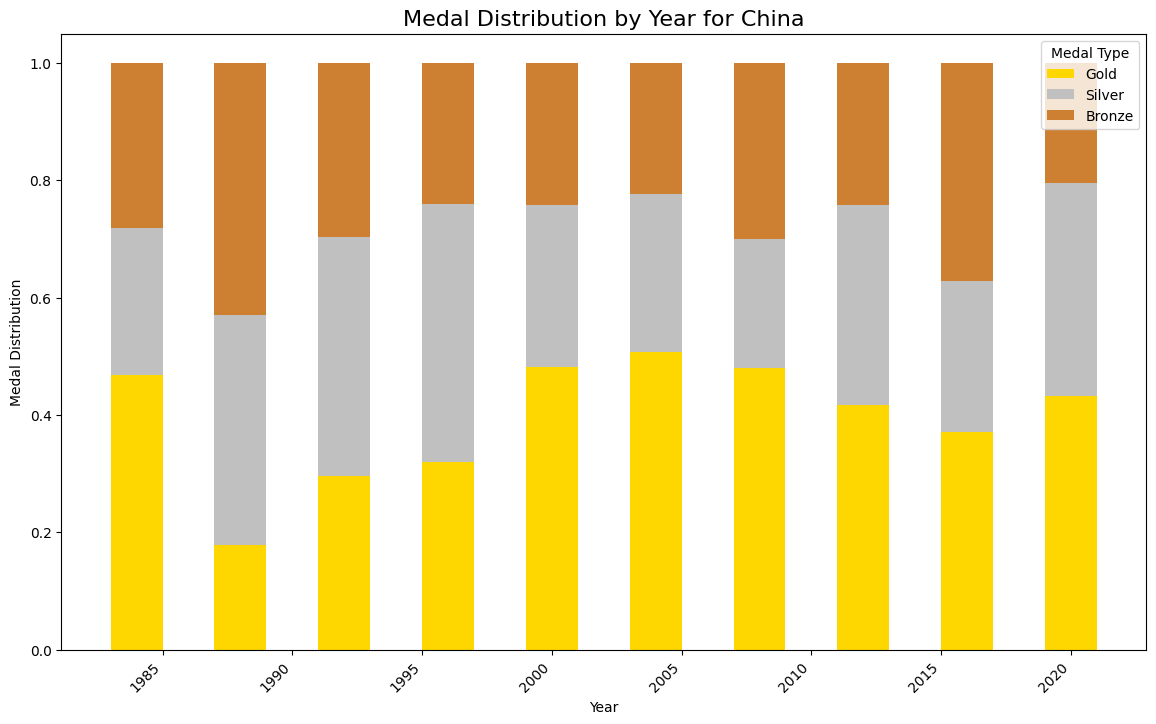

In [ ]:
raspodela_po_medaljama('China', data)

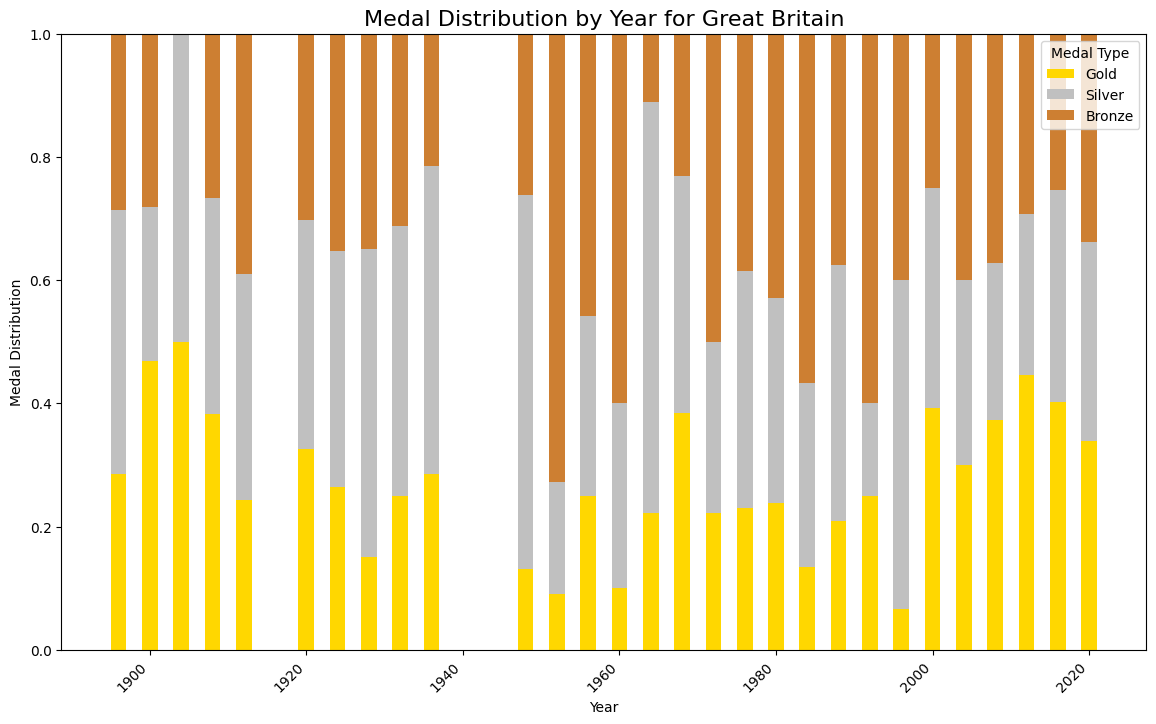

In [ ]:
raspodela_po_medaljama('Great Britain', data)

**Sada sam racunao broj razlicitih osvajaca po godinama**

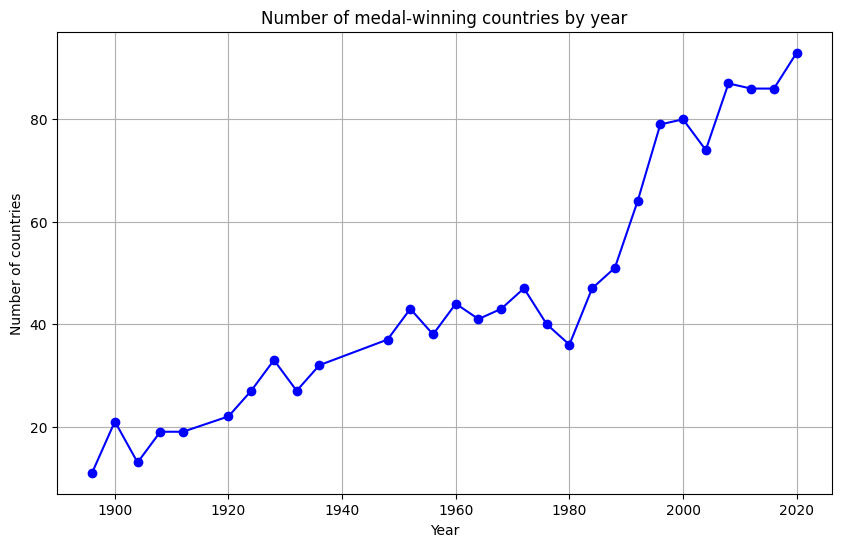

In [38]:
# Grupisem zemlje po godinama, a zatim odredjujem koliko u posmatranoj godini ima jedinstvenih
broj_osvajaca = data.groupby('Year')['Country_Name'].nunique()

# Graficki prikaz
plt.figure(figsize=(10, 6))
plt.plot(broj_osvajaca.index, broj_osvajaca.values, marker='o', linestyle='-', color='b')
plt.title('Number of medal-winning countries by year')
plt.xlabel('Year')
plt.ylabel('Number of countries')
plt.grid(True)
plt.show()

**A zatim sam izracunao i broj novih osvajaca za svaku godinu.**

In [39]:
# Prazan recnik
novi_osvajaci = {}

# Ovde cu svrstavati sve prethodne osvajace
prethodni_osvajaci = set()

# Iteracija kroz svaku godinu u DataFrame-u
for godina in sorted(data['Year'].unique()):
    # Uzimanje podataka za posmatranu godinu
    data_godina = data[data['Year'] == godina]

    # Trazenje novih osvajaca, oduzimanjem svih vec postojecih(skupovno gledano(razlika dva skupa))
    trenutno_osvajaci = set(data_godina['Country_Name'])
    novi = trenutno_osvajaci - prethodni_osvajaci

    # Brojanje novih osvajaca za posmatranu godinu
    novi_osvajaci[godina] = len(novi)

    # Na sve prethodne osvajace nadodajem one koji su zabelezeni u ovoj godini(skupovno gledano unija)
    prethodni_osvajaci.update(trenutno_osvajaci)

# Ispisivanje rezultata
for godina, broj in novi_osvajaci.items():
    print(f"{godina}. godine bilo je {broj} novih osvajaca medalja.")

1896. godine bilo je 11 novih osvajaca medalja.
1900. godine bilo je 11 novih osvajaca medalja.
1904. godine bilo je 0 novih osvajaca medalja.
1908. godine bilo je 3 novih osvajaca medalja.
1912. godine bilo je 0 novih osvajaca medalja.
1920. godine bilo je 4 novih osvajaca medalja.
1924. godine bilo je 7 novih osvajaca medalja.
1928. godine bilo je 4 novih osvajaca medalja.
1932. godine bilo je 2 novih osvajaca medalja.
1936. godine bilo je 1 novih osvajaca medalja.
1948. godine bilo je 8 novih osvajaca medalja.
1952. godine bilo je 3 novih osvajaca medalja.
1956. godine bilo je 3 novih osvajaca medalja.
1960. godine bilo je 7 novih osvajaca medalja.
1964. godine bilo je 3 novih osvajaca medalja.
1968. godine bilo je 3 novih osvajaca medalja.
1972. godine bilo je 3 novih osvajaca medalja.
1976. godine bilo je 2 novih osvajaca medalja.
1980. godine bilo je 3 novih osvajaca medalja.
1984. godine bilo je 6 novih osvajaca medalja.
1988. godine bilo je 7 novih osvajaca medalja.
1992. godin

**Prepravkom jednog koda koji sam vec imao izracunao sam procentualno koliku prednost imaju zemlje kao organizatori u odnosu na godine kada nisu organizatori, ovoga puta sam posebno racunao za svaku godinu domacinstva i koristio udeo medalja umesto ukupnog broja medalja. A zatim sam izracunao prosek za sve zemlje osim prvih nekoliko.  Nema previse smisla posmatrati prvih nekoliko, jer se ta prednost vise ne javlja u toj meri i vidno samo kvari krajnji rezultat.**

In [40]:
# Kreiram prazan DataFrame sa unapred nazvanim kolonama
results = pd.DataFrame(columns=['Country_Name', 'Year', 'Percentage_Host', 'Avg_Percentage_Non_Host'])

# I praznu listu za redove
rows = []

# Ukupan broj medalja po godini
total_medals_per_year = data.groupby('Year')[['Gold', 'Silver', 'Bronze']].sum().sum(axis=1)

# Prolazim kroz sve zemlje iz skupa Domacini
for country in Domacini:
    # Podaci za zemlju kada je bila domacin
    host_years = data[(data['Country_Name'] == country) & (data['Country_Name'] == data['Host_country'])]

    # Podaci za zemlju kada nije bila domacin
    non_host_years = data[(data['Country_Name'] == country) & (data['Country_Name'] != data['Host_country'])]

    # Prosecan procenat osvojenih medalja u godinama kada zemlja nije bila domacin
    total_medals_non_host_years = non_host_years.groupby('Year')[['Gold', 'Silver', 'Bronze']].sum()
    percentage_medals_non_host = (total_medals_non_host_years[['Gold', 'Silver', 'Bronze']].sum(axis=1) / total_medals_per_year.loc[total_medals_non_host_years.index]).mean()

    # Ukupan broj medalja (zlatne + srebrne + bronzane) za sve godine kada je zemlja bila domacin
    total_medals_host_years = host_years.groupby('Year')[['Gold', 'Silver', 'Bronze']].sum()

    # Procenat osvojenih medalja zemlje u godinama domacinstva, za svaku godinu odvojeno
    for year, medals in total_medals_host_years.iterrows():
        percentage_medals_host = medals.sum() / total_medals_per_year.loc[year]

        # Dodavanje rezultata u listu
        rows.append({
            'Country_Name': country,
            'Year': year,
            'Percentage_Host': percentage_medals_host,
            'Avg_Percentage_Non_Host': percentage_medals_non_host
        })
# Kreiranje DataFrame-a iz liste rows
results = pd.DataFrame(rows)
results = results.sort_values(by='Year')
results = results.reset_index(drop=True)
# Ovde pomocu dobijenih rezultata izracunavam kolonu 'Advantage_Percentage', koja u procentima prikazuje koliko bolji/losiji ucinak
# ima zemlja u godini domacinstva
results['Advantage_Percentage'] = ((results['Percentage_Host'] / results['Avg_Percentage_Non_Host'])-1)*100

# Ovde nailazim na problem sa time sto su u pocetnim godinama zemlje imale daleko vecu prednost, koja nije uporediva sa danasnjom
# I samo bi pokvarila krajnji rezultat, pa zbog toga uzimam podatke tek od Finske

procentualna_prednost = (results['Advantage_Percentage'].iloc[6:].sum())/22
print(procentualna_prednost)
results

120.84765983141246


,Country_Name,Year,Percentage_Host,Avg_Percentage_Non_Host,Advantage_Percentage
0,Greece,1896,0.385246,0.004870,7810.989222
1,France,1900,0.359155,0.040767,781.004755
2,United States,1904,0.825000,0.156978,425.551945
3,Great Britain,1908,0.450617,0.048979,820.026794
4,Sweden,1912,0.205047,0.035779,473.098010
5,Belgium,1920,0.094382,0.010446,803.498248
6,France,1924,0.100529,0.040767,146.597243
7,Netherlands,1928,0.058104,0.018892,207.557781
8,United States,1932,0.297688,0.156978,89.636890
9,Germany,1936,0.229381,0.083606,174.360133


**Za kraj imamo procenu osvojenih medalja za zemlje na osnovu linearne regresije sa dodatom prednosti za slucaj da je zemlja domacin. A predikcija je zasnovana na godini koja se bira u samoj funkciji i  broju medalja do te godine.**

**Nacin izracunavanja koji sam izabrao je prednost koju su prosecno pravile zemlje u poslednjih 22 domacinstava, a kako zemlje koje imaju veliki broj medalja na ovaj nacin dobijaju nemogucu prednost za zemlje preko 50 medalja usporio sam rast procenta tako sto sam podelio sa prirodnim logaritmom (np.log1p(predicted_medals*20)). Takodje ovaj model nije primenjiv na zemlje sa malim brojem medalje jer im daje preveliku prednost, pa sam kod njih faktor domacinstva ostavio nepromenjen.**

In [41]:
def predvidjanje_broja_medalja(data, country, year, host_country, host_advantage=procentualna_prednost/100):
    # Filtriranje podataka za izabranu zemlju do zadate godine
    country_data = data[(data['Country_Name'] == country) & (data['Year'] < year)]

    # Grupisem podatke po godinama za posmatranu zemlju kako bih zatim nasao ukupan broj medalja za tu godinu
    yearly_medals = country_data.groupby('Year')[['Gold', 'Silver', 'Bronze']].sum().sum(axis=1).reset_index()

    # Dodavanje kolone za ukupne medalje
    yearly_medals.columns = ['Year', 'Total_Medals']

    # Kreiranje regresionog modela
    X = yearly_medals['Year'].values.reshape(-1, 1)
    y = yearly_medals['Total_Medals']
    model = LinearRegression()
    model.fit(X, y)

    # Predikcija broja medalja za zadatu godinu
    predicted_medals = model.predict(np.array([[year]]))[0]

    # Faktor domacinstva
    if host_country and host_country == country:
      if predicted_medals > 50:
        predicted_medals *=((1 + host_advantage))/np.log1p(predicted_medals/20)
      else:
        predicted_medals *=((1 + host_advantage))

    # Ispisivanje predikcije
    print(f"Predikcija za broj osvojenih medalja za zemlju {country} u godini {year} je {predicted_medals:.2f} medalja.")

    return predicted_medals

In [42]:
predicted_medals = predvidjanje_broja_medalja(data, 'France', 2024, 'France')

Predikcija za broj osvojenih medalja za zemlju France u godini 2024 je 61.04 medalja.


In [43]:
predicted_medals = predvidjanje_broja_medalja(data, 'United States', 2028, 'United States')

Predikcija za broj osvojenih medalja za zemlju United States u godini 2028 je 133.12 medalja.


In [44]:
predicted_medals = predvidjanje_broja_medalja(data, 'Russia', 1980, 'Russia')

Predikcija za broj osvojenih medalja za zemlju Russia u godini 1980 je 138.91 medalja.


In [45]:
predicted_medals = predvidjanje_broja_medalja(data, 'China', 2008, 'China')

Predikcija za broj osvojenih medalja za zemlju China u godini 2008 je 103.91 medalja.


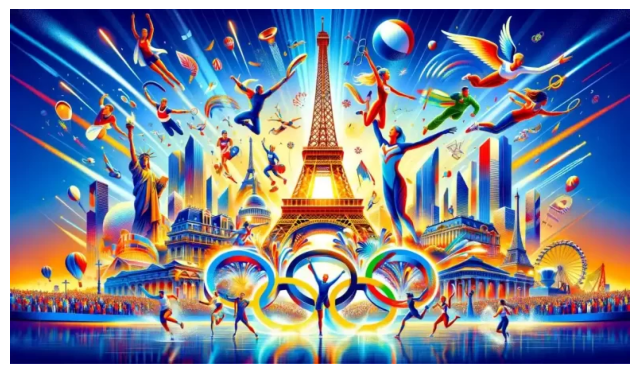

In [46]:
img = plt.imread('Olimpijske-igre-2024.webp')
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.show()